### Coefficient combinations for the ice sheet

This script was ran twice: Once with the entire AWS data from all PROMICE stations located on the ice shield, to retrieve coefficients per satellite and station. The regression results for some stations showed a weak correlation with the remotely sensed data. This is primarily the case for stations that are close to the ice sheet margin. Temperatures here are mostly at around 0 degrees, as it can be seen in the figures. With a majority of data at around freezing point, the regression is very prone to noise resulting in coefficients of very limited explanatory power. Stations and their coefficients that achieved a determination coefficient of less than 0.8 after calibration, were excluded from the analysis to prevent their influence on the calibration of the sensors for the ice sheet. Other factors that might affect the poor goodness of fit are the heterogeneity of the 1km pixel that the aws measurements are being compared to, moving ice / snow masses that might affect the calibration of the aws sensor, or dust that is transported from the ice free parts towards the ice sheet margin. 

After the exclusion of these stations, the script was ran again with a reduced aws_data dataset.

In [26]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import itertools
sns.set_theme(style="darkgrid")

# Show current working directory
# print("Current Working Directory: ", os.getcwd())

# File paths
aws_path = 'C:/Users/simon/OneDrive - University of Copenhagen/Documents/Arbeitsmappe/GEMLST/GEMLST/GEMLST_MODIS/Data/PROMICE/output/daily_prepped.csv'

In [47]:
print(selected_stations)
print(len(selected_stations))

['CEN', 'EGP', 'KPC_U', 'THU_U', 'KPC_L', 'THU_L', 'SCO_U', 'UPE_U', 'KAN_L', 'KAN_M', 'KAN_U']
11


In [44]:
# Load data
aws_data = pd.read_csv(aws_path)

# Filter to include only stations where the follonwing analysis revealed a good fit of min. r^2 0.8.
aws_data = aws_data[aws_data['aws'].isin(selected_stations)]  

# List all files in the directory "Data/Extraction_ICE
file_list = os.listdir('./Data/Extraction_ICE')
table_list = []

# Change variable names
def process_satellite_data(df):
    lst_aliases = ['MOD_LST_Day', 'MOD_LST_Night', 'MYD_LST_Day', 'MYD_LST_Night', 'JAXA_LST_AVE', 'VIIRS_LST_1KM_C']
    for alias in lst_aliases:
        if alias in df.columns:
            df.rename(columns={'id': 'aws', alias: 'est_temp'}, inplace=True)
            # Keep only observations where est_temp is above 0
            df = df[df['est_temp'] >= 0]



# Load extracted satellite data from the PROMICE station locations
def import_extracted_data(file_list):
    for file in file_list:
        # path = ('./Data/Extraction_ICE/XXX').replace('XXX', file)
        df = pd.read_csv(f'./Data/Extraction_ICE/{file}')
        file_name = str(file).split('.')[0]
        process_satellite_data(df)
        globals()[file_name] = df
        # Add df to the table list

import_extracted_data(file_list)


In [45]:
df_modd1 = pd.merge(
    aws_data,
    MOD_DAY_LST_PROMICE,
    on=['aws', 'date'],
    how='inner'
)
df_modd1 = df_modd1.dropna()

df_modn1 = pd.merge(
    aws_data,
    MOD_NIGHT_LST_PROMICE,
    on=['aws', 'date'],
    how='inner'
)
df_modn1 = df_modn1.dropna()

df_mydd1 = pd.merge(
    aws_data,
    MYD_DAY_LST_PROMICE,
    on=['aws', 'date'],
    how='inner'
)
df_mydd1 = df_mydd1.dropna()

df_mydn1 = pd.merge(
    aws_data,
    MYD_NIGHT_LST_PROMICE,
    on=['aws', 'date'],
    how='inner'
)
df_mydn1 = df_mydn1.dropna()

df_jaxa_a = pd.merge(
    aws_data,
    JAXA_A_LST_PROMICE,
    on=['aws', 'date'],
    how='inner'
)
df_jaxa_a = df_jaxa_a.dropna()

df_jaxa_d = pd.merge(
    aws_data,
    JAXA_D_LST_PROMICE,
    on=['aws', 'date'],
    how='inner'
)
df_jaxa_d = df_jaxa_d.dropna()

df_viirs_day = pd.merge(
    aws_data, 
    VIIRS_DAY_LST_PROMICE,
    on=['aws', 'date'],
    how='inner'
)
df_viirs_day = df_viirs_day.dropna()

df_viirs_night = pd.merge(
    aws_data,
    VIIRS_NIGHT_LST_PROMICE,
    on=['aws', 'date'],
    how='inner'
)
df_viirs_night = df_viirs_night.dropna()


### Retrieve coefficients and make plots per satellite

--- Results for MOD_Terra_DAY ---


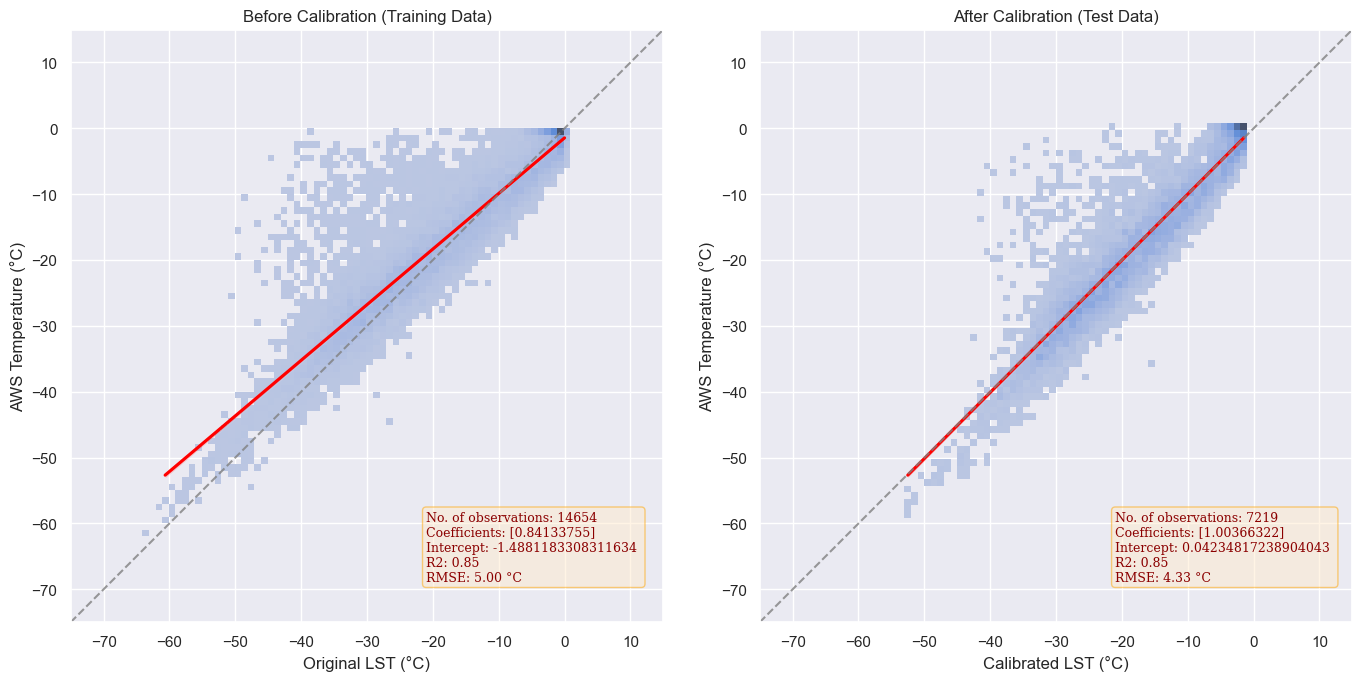

--- Results for MOD_Terra_NIGHT ---


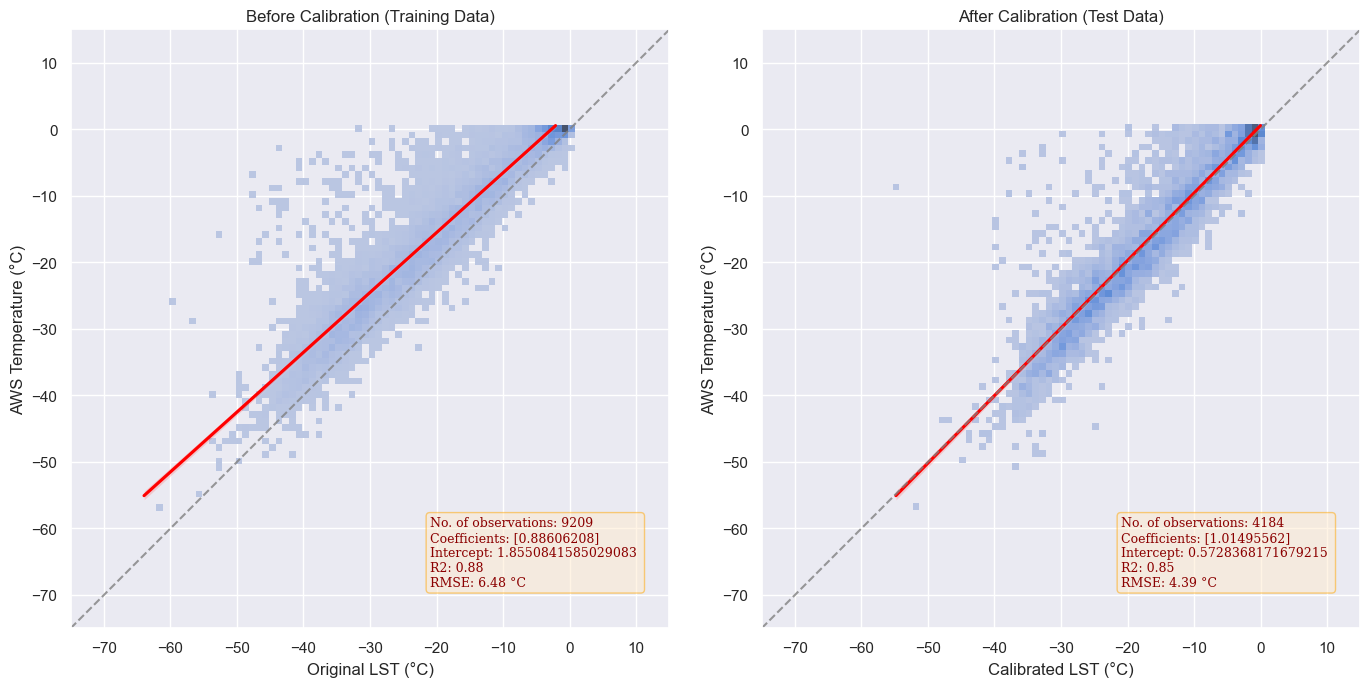

--- Results for MYD_Aqua_DAY ---


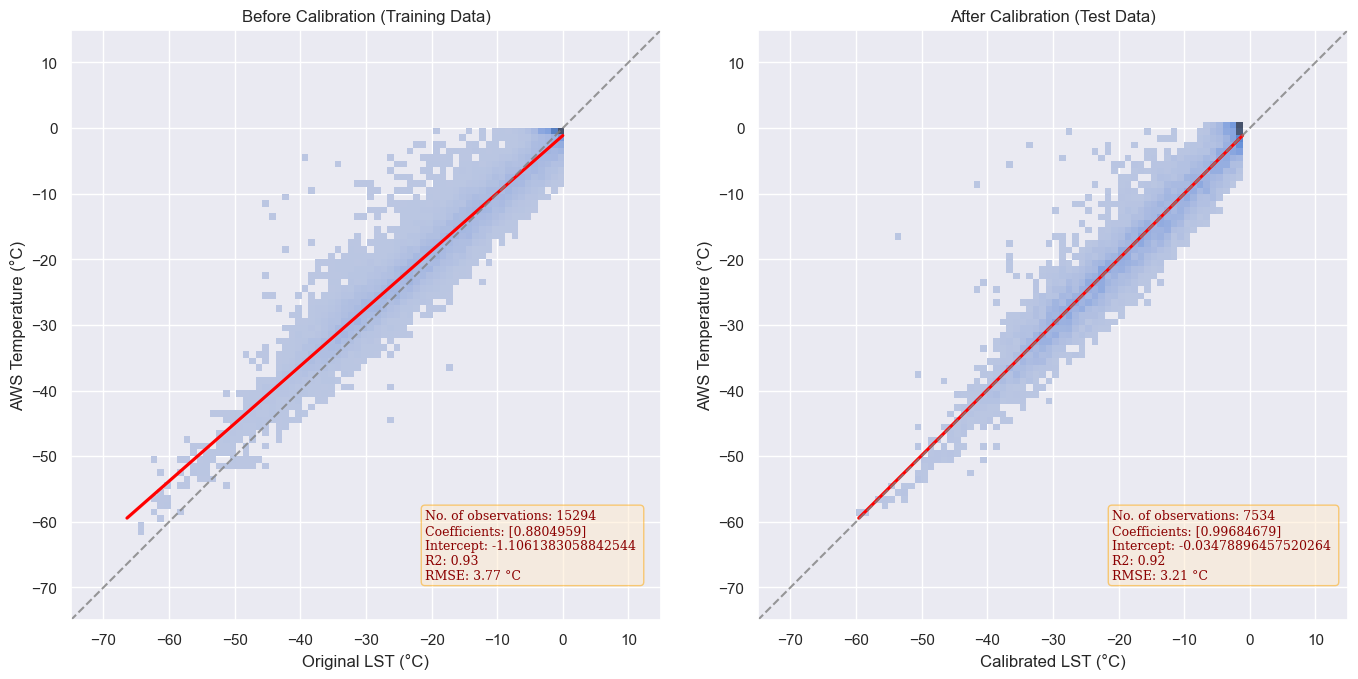

--- Results for MYD_Aqua_NIGHT ---


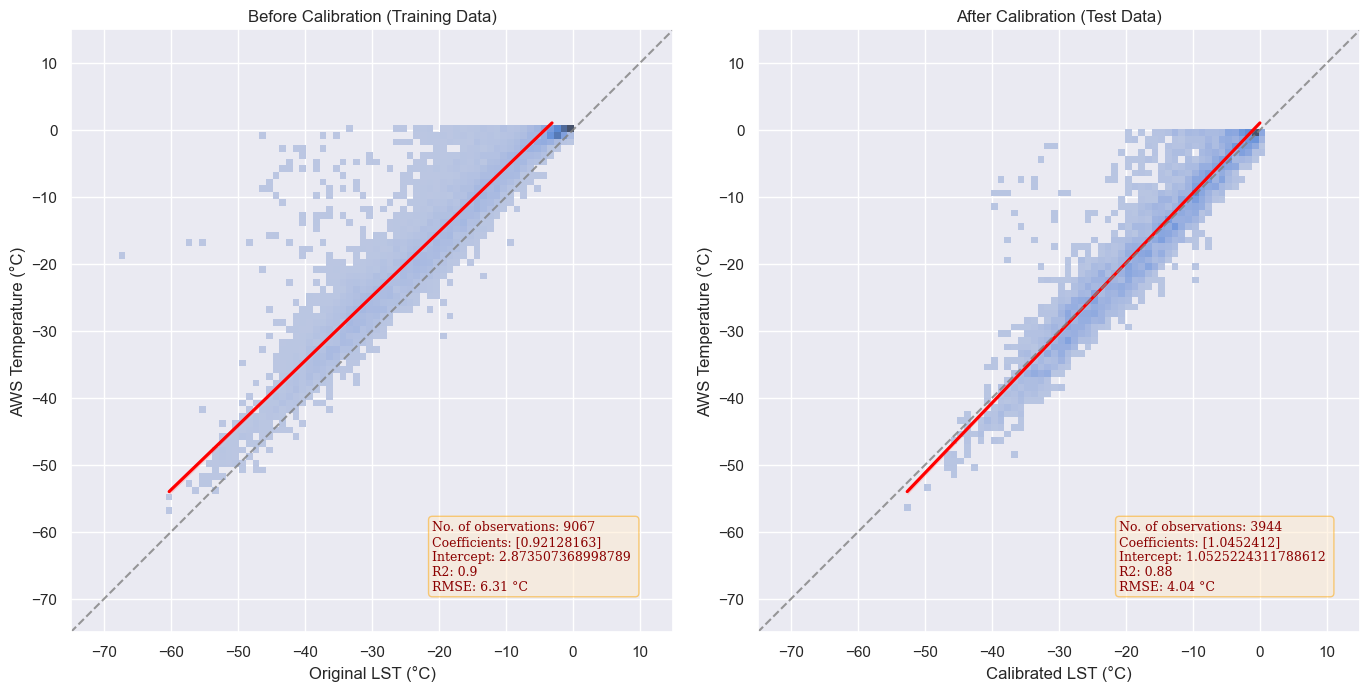

--- Results for JAXA_A ---


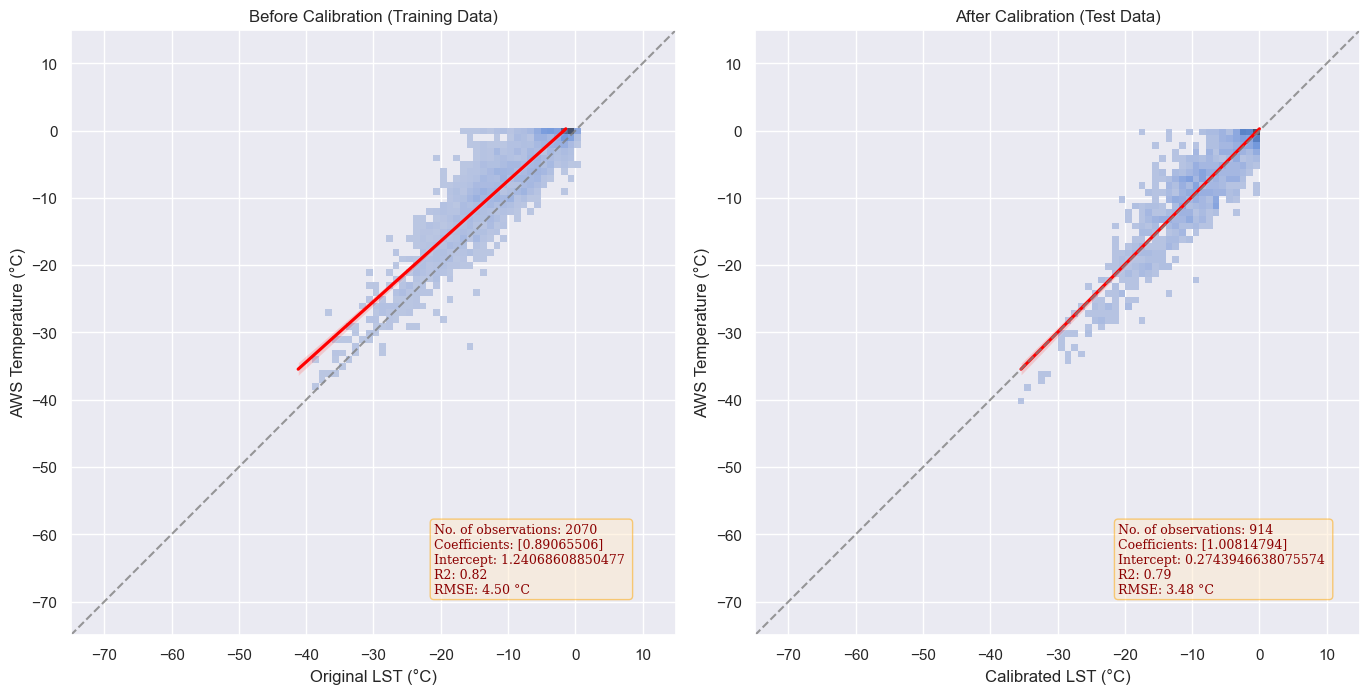

--- Results for JAXA_D ---


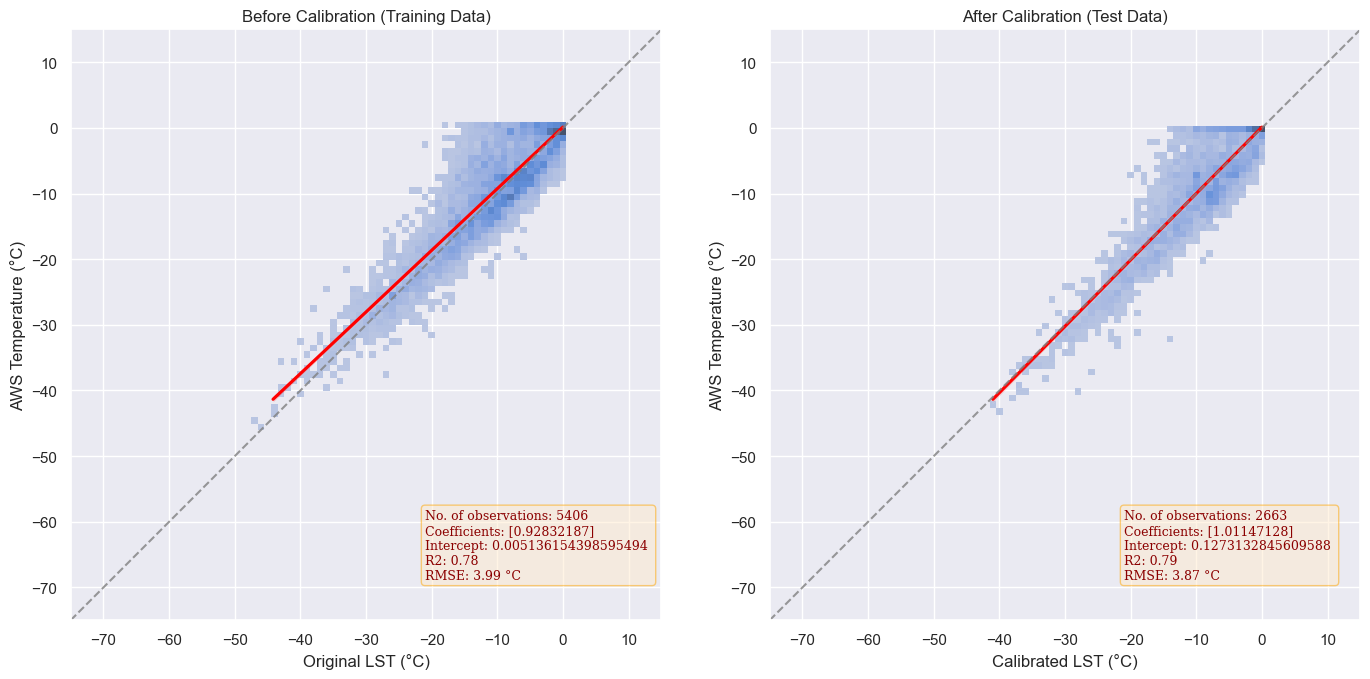

--- Results for VIIRS_DAY ---


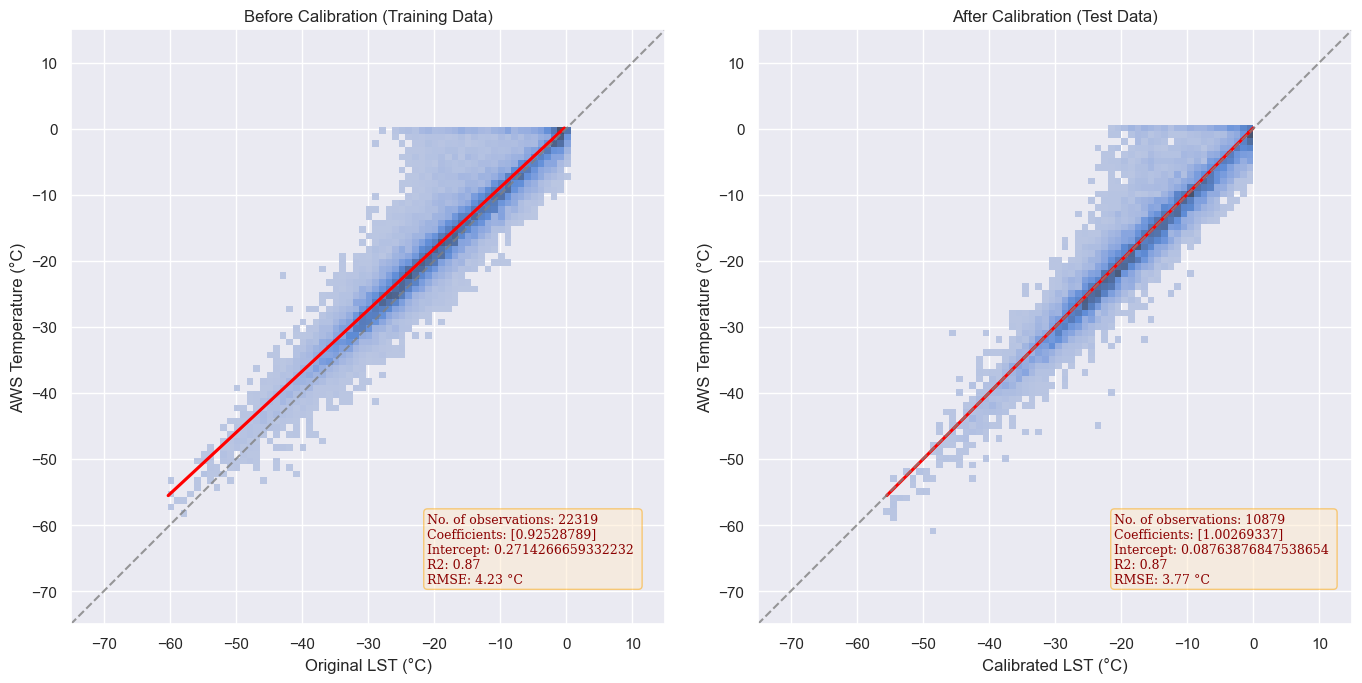

--- Results for VIIRS_NIGHT ---


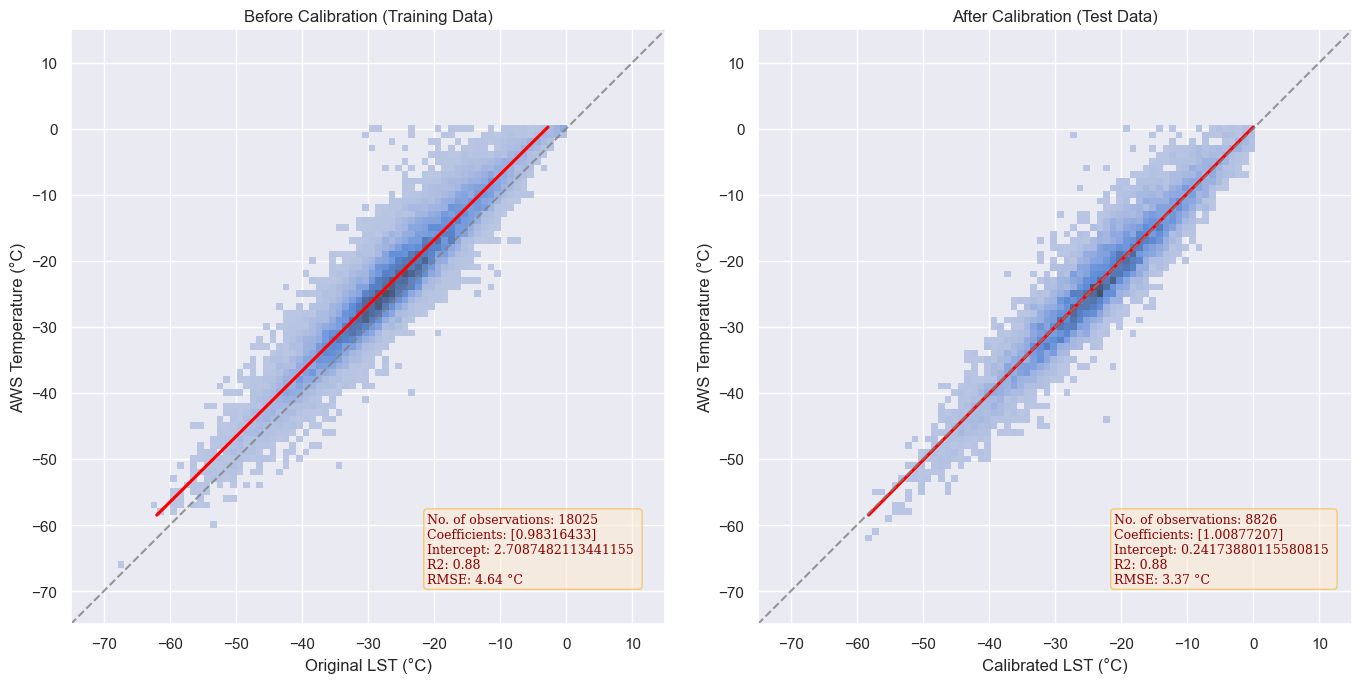

In [18]:
dfs = [df_modd1, df_modn1, df_mydd1, df_mydn1, df_jaxa_a, df_jaxa_d, df_viirs_day, df_viirs_night]
labels = ["MOD_Terra_DAY", "MOD_Terra_NIGHT", "MYD_Aqua_DAY", "MYD_Aqua_NIGHT", "JAXA_A", "JAXA_D", "VIIRS_DAY", "VIIRS_NIGHT"]


def split_mod_viz(df):

    df = df[df['est_temp'] <= 0]

    # Split data into training and testing sets (2/3 training, 1/3 testing)
    train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

    # Regression model fit and prediction
    model = LinearRegression()
    model.fit(train_df[['est_temp']], train_df['t_surf'])
    model.predict(test_df[['est_temp']])
    r2_train = round(model.score(train_df[['est_temp']], train_df['t_surf']), 2)

    # return {
    #     "n_obs": len(df),
    #     "coef": model.coef_[0],
    #     "intercept": model.intercept_,
    #     'R-squared': model.score(test_df[['est_temp']], test_df['t_surf']),
    #     'rmse_before': ((test_df['est_temp'] - test_df['t_surf']) ** 2).mean() ** 0.5,
    #     'rmse_after': ((test_df['est_temp'] * model.coef_[0] + model.intercept_ - test_df['t_surf']) ** 2).mean() ** 0.5
    #     }

    # # The coefficients
    # print('No. of observations (total df): ', len(df))
    # print('Coefficients: ', model.coef_)
    # print('Intercept: ', model.intercept_)
    # print('R-squared: ', model.score(test_df[['est_temp']], test_df['t_surf']))

    # Apply calibration to test dataset
    test_df['lst_calibrated'] = test_df['est_temp'] * model.coef_[0] + model.intercept_
    test_df = test_df[test_df['lst_calibrated'] <= 0]

    # Reveal coefficients of the calibrated model
    model2 = LinearRegression()
    model2.fit(test_df[['lst_calibrated']], test_df['t_surf'])
    r2_test = round(model2.score(test_df[['lst_calibrated']], test_df['t_surf']), 2)

    # Calculate RMSE of the calibration results
    rmse_before = ((test_df['est_temp'] - test_df['t_surf']) ** 2).mean() ** 0.5
    rmse_after = ((test_df['lst_calibrated'] - test_df['t_surf']) ** 2).mean() ** 0.5
    # print(f"RMSE before calibration: {rmse_before:.2f} °C")
    # print(f"RMSE after calibration: {rmse_after:.2f} °C\n")
    s1 = f'No. of observations: {len(train_df)} \nCoefficients: {model.coef_} \nIntercept: {model.intercept_} \nR2: {r2_train} \nRMSE: {rmse_before:.2f} °C'
    s2 = f'No. of observations: {len(test_df)} \nCoefficients: {model2.coef_} \nIntercept: {model2.intercept_} \nR2: {r2_test} \nRMSE: {rmse_after:.2f} °C'

    ### GRAPHICAL VISUALIZATION ###
    # Create comparison plot of original vs calibrated values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    # Add 1:1 reference line 
    min_val = -75
    max_val = 15

    # 
    font = {'family': 'serif',
            'color':  'darkred',
            'weight': 'normal',
            'size': 9,
            }
    
    bbox = dict(
        boxstyle='round', 
        fc='blanchedalmond', 
        ec='orange', 
        alpha=0.5)

    # 2d HISTOGRAM PLOTS
    # Original est_temp plot
    sns.histplot(ax=ax1, data=train_df, x='est_temp', y='t_surf', bins=60, discrete=True)
    sns.regplot(ax=ax1, data=test_df, x='est_temp', y='t_surf', scatter=False, color='red')
    ax1.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    ax1.text(0.6, 0.07, s1, fontdict=font, bbox=bbox, transform=ax1.transAxes, horizontalalignment='left')
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)
    ax1.set_xlabel('Original LST (°C)')
    ax1.set_ylabel('AWS Temperature (°C)')
    ax1.set_title('Before Calibration (Training Data)')
    ax1.set_aspect('equal')

    # Calibrated est_temp plot
    sns.histplot(ax=ax2, data=test_df, x='lst_calibrated', y='t_surf', bins=60, discrete=True)
    sns.regplot(ax=ax2, data=test_df, x='lst_calibrated', y='t_surf', scatter=False, color='red')
    ax2.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    ax2.text(0.6, 0.07, s2, fontdict=font, bbox=bbox, transform=ax2.transAxes, horizontalalignment='left')
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)
    ax2.set_xlabel('Calibrated LST (°C)')
    ax2.set_ylabel('AWS Temperature (°C)')
    ax2.set_title('After Calibration (Test Data)')
    ax2.set_aspect('equal')
    plt.tight_layout()
    plt.show()


###### PRINT FOR EACH SATELLITE
for i, df in enumerate(dfs):
    print(f"--- Results for {labels[i]} ---")
    split_mod_viz(df)


In [ ]:
#%% different scale plots - Shunan
# Integrate this chunk into the plots to make colorbars aligned with the jointplot
sns.set_theme(style="darkgrid", font="Arial", font_scale=2)
g = sns.jointplot(x="visnirAlbedo", y="Albedo_theta<70d", data=df, kind="hist", 
                  height=8, xlim=(0,1), ylim=(0,1), cbar=True, vmin=0, vmax=55)
g.ax_joint.axline((0, 0), (1, 1), linewidth=1, color='k', linestyle='--')                       
g.plot_joint(sns.regplot, color='r', scatter=False)
g.set_axis_labels(xlabel="visnir albedo", ylabel="PROMICE albedo")

# ref https://stackoverflow.com/a/60849048/13318759
# get the current positions of the joint ax and the ax for the marginal x
pos_joint_ax = g.ax_joint.get_position()
pos_marg_x_ax = g.ax_marg_x.get_position()
# reposition the joint ax so it has the same width as the marginal x ax
g.ax_joint.set_position([pos_joint_ax.x0, pos_joint_ax.y0, pos_marg_x_ax.width, pos_joint_ax.height])
# reposition the colorbar using new x positions and y positions of the joint ax
g.fig.axes[-1].set_position([.96, pos_joint_ax.y0, .07, pos_joint_ax.height])


### Coefficients per station (Plots)

--- Results for station CEN ---


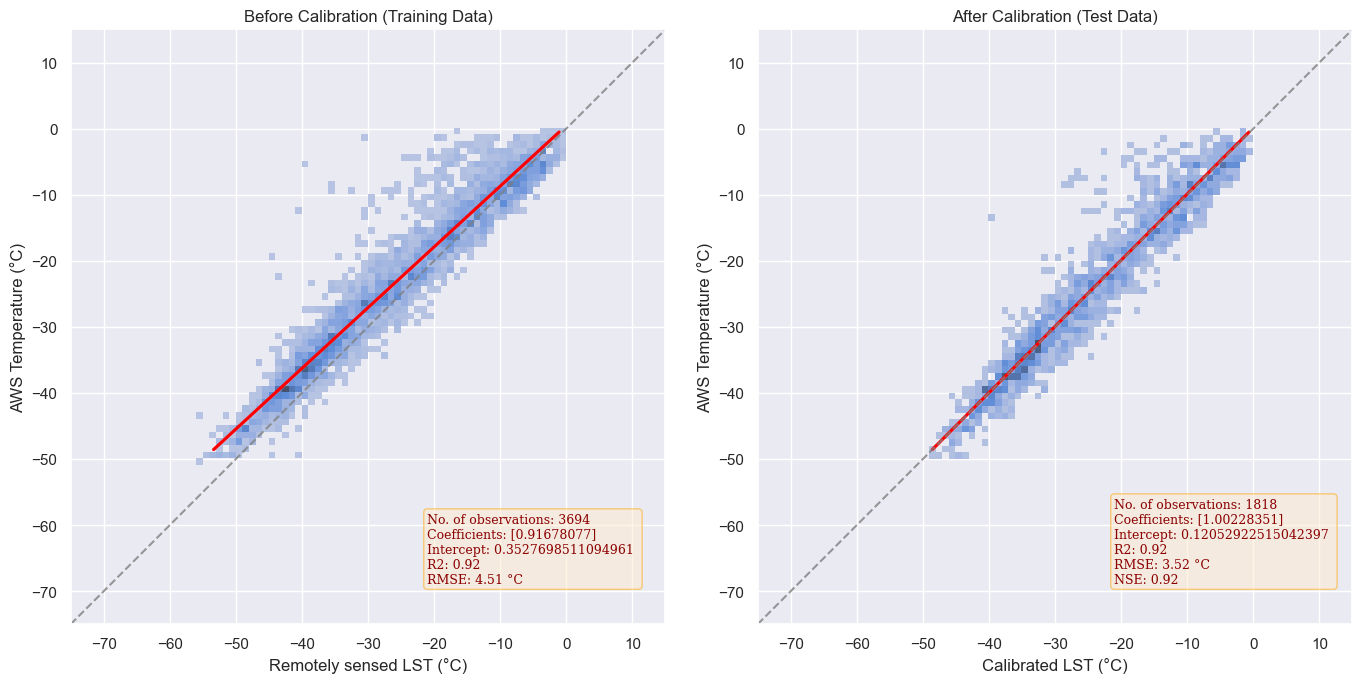

--- Results for station CP1 ---


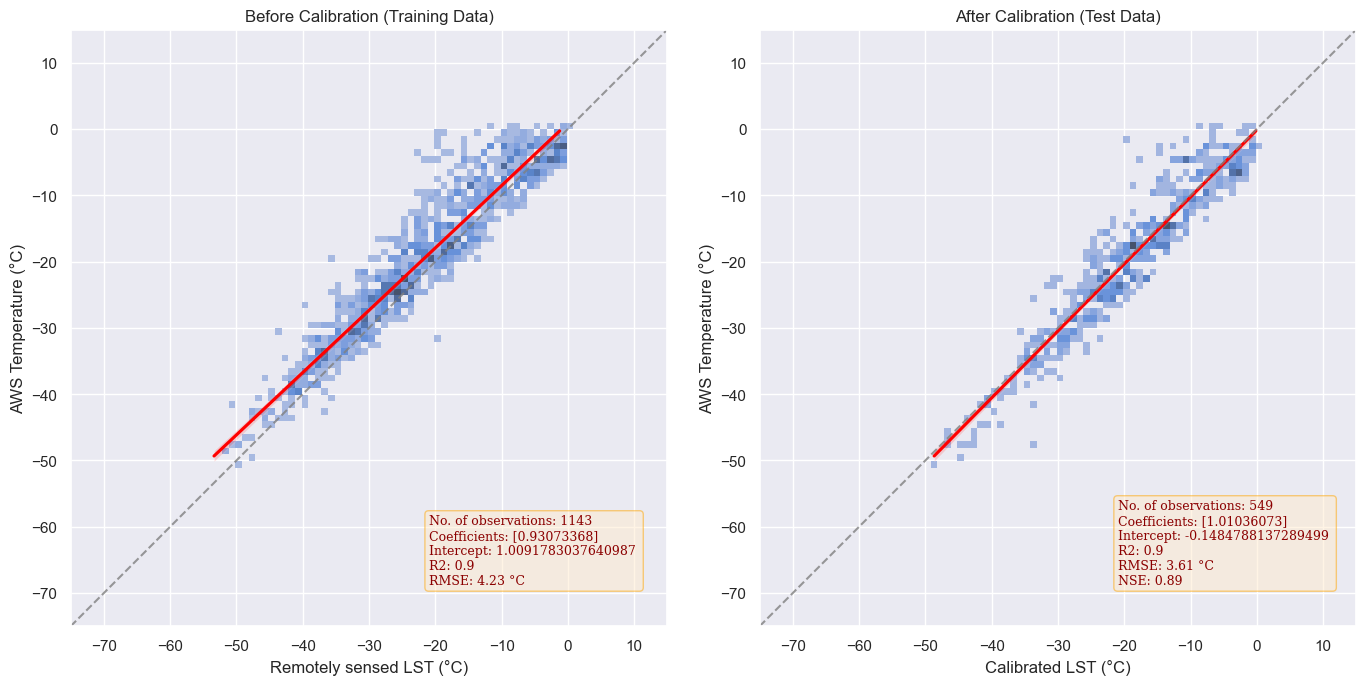

--- Results for station DY2 ---


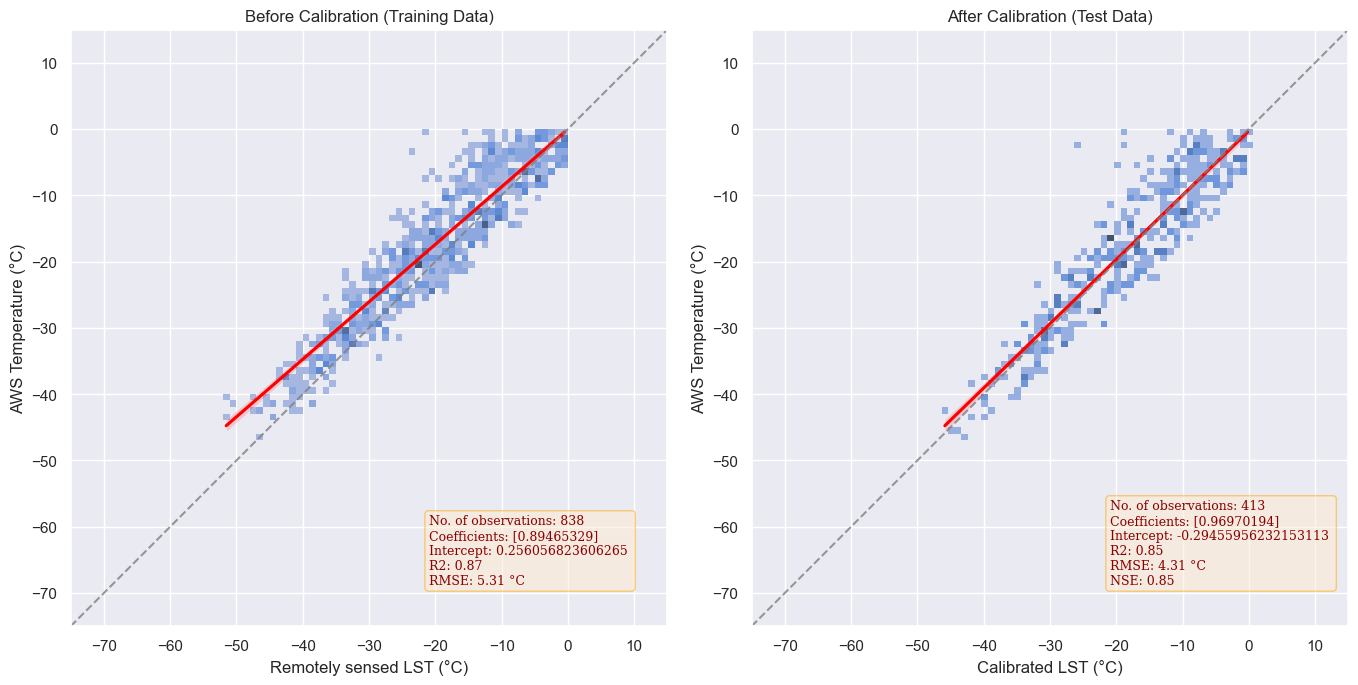

--- Results for station EGP ---


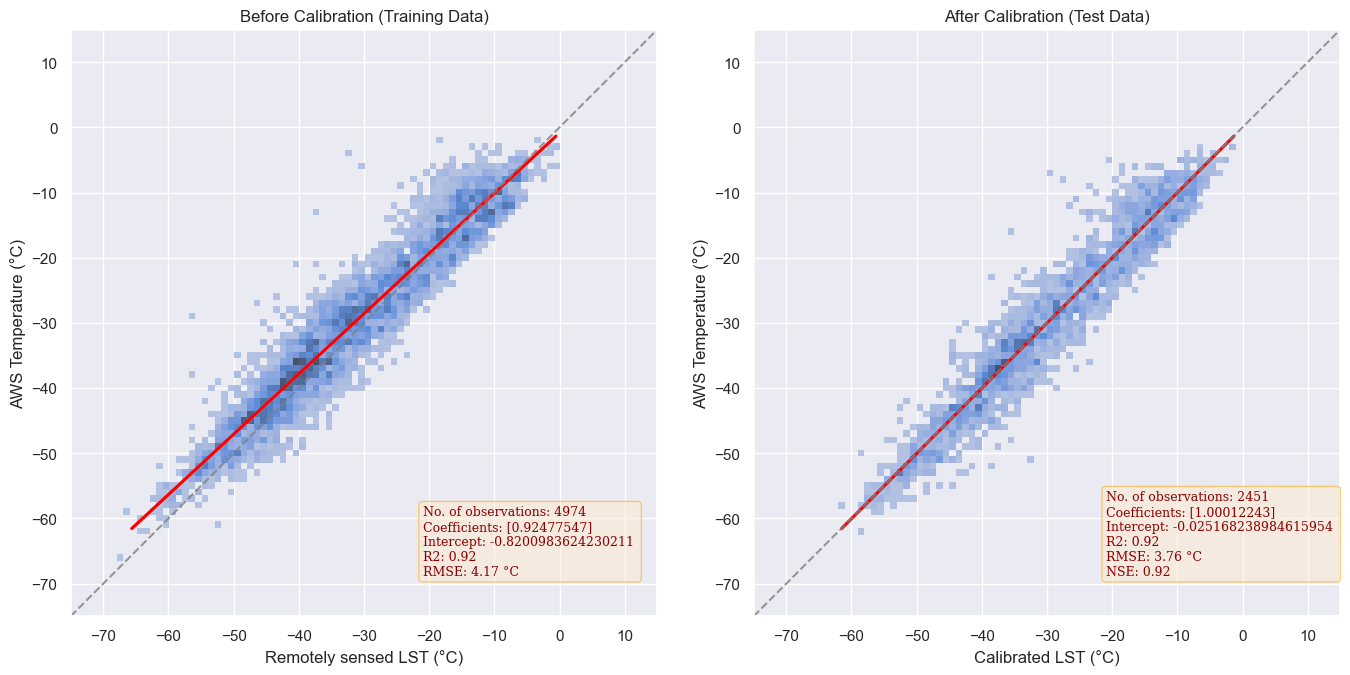

--- Results for station HUM ---


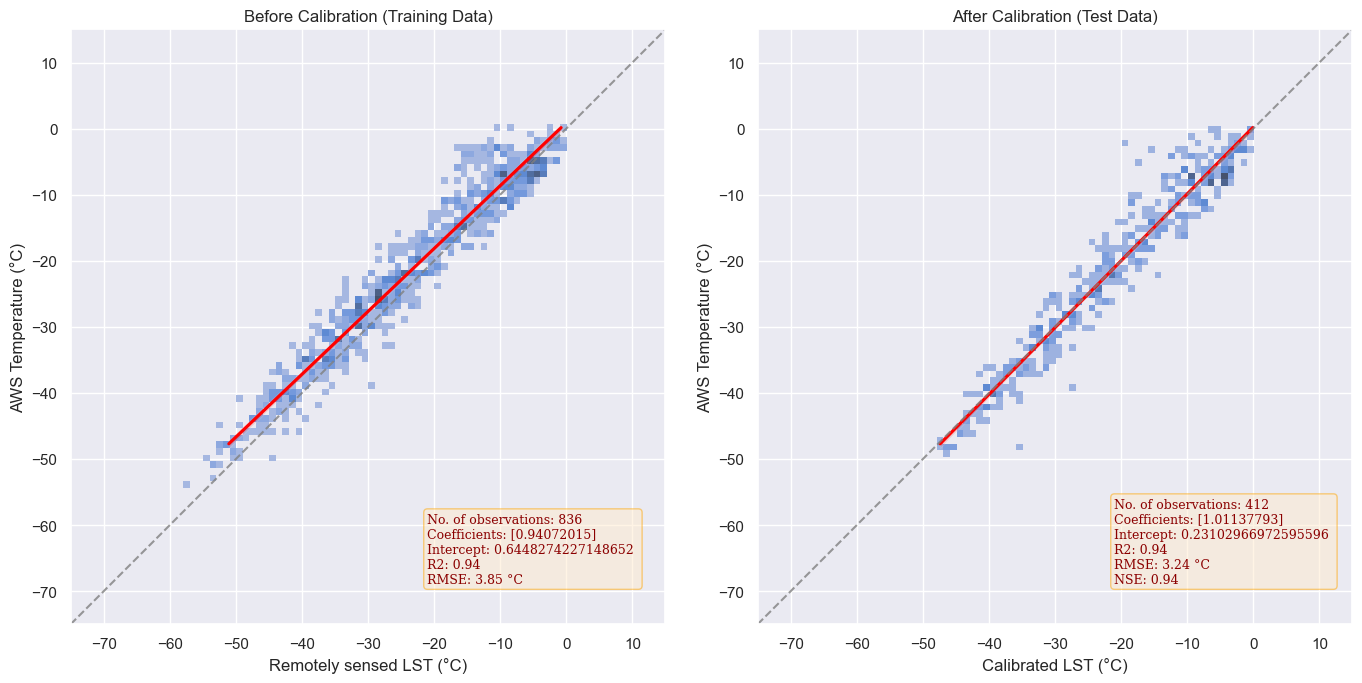

--- Results for station JAR ---


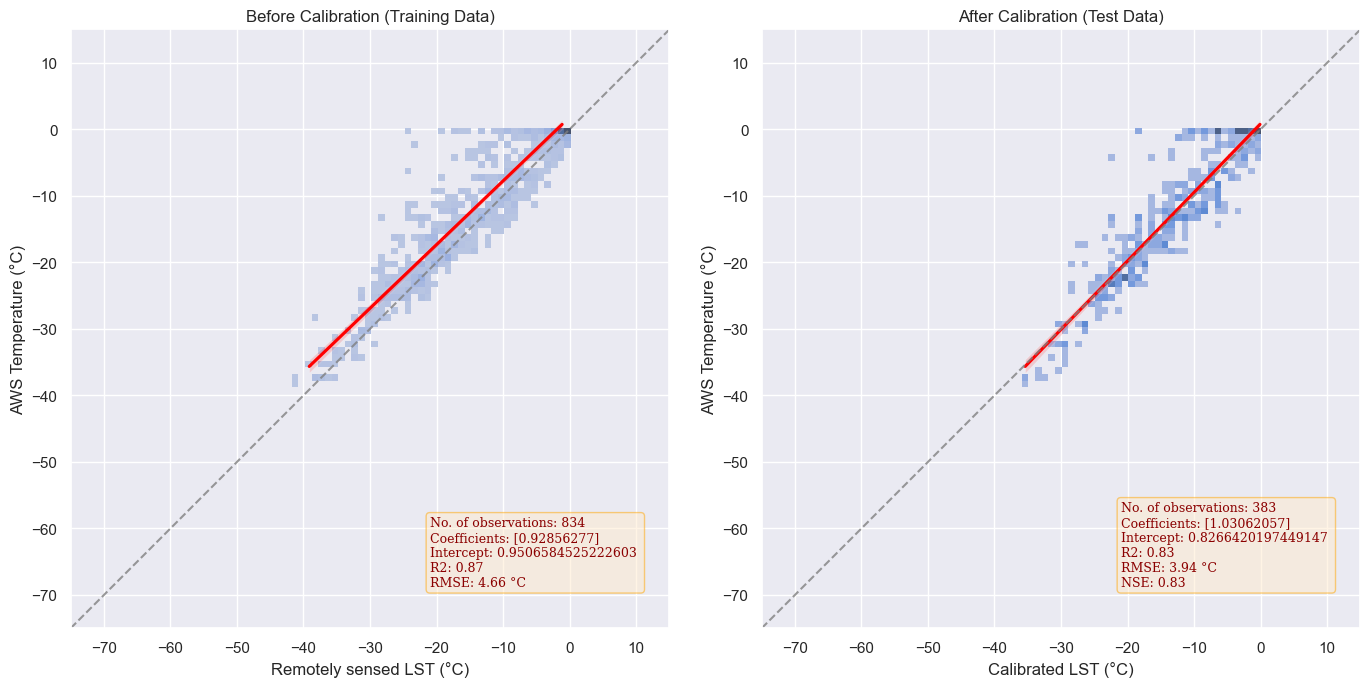

--- Results for station KAN_L ---


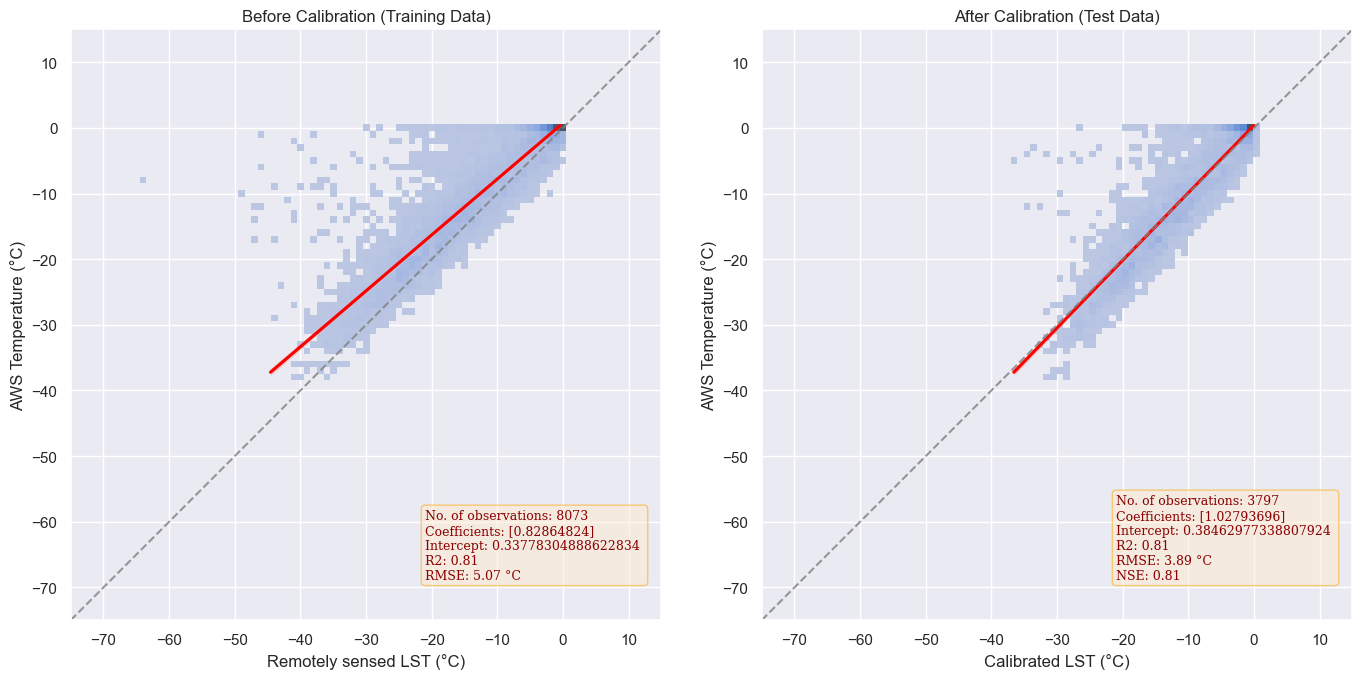

--- Results for station KAN_M ---


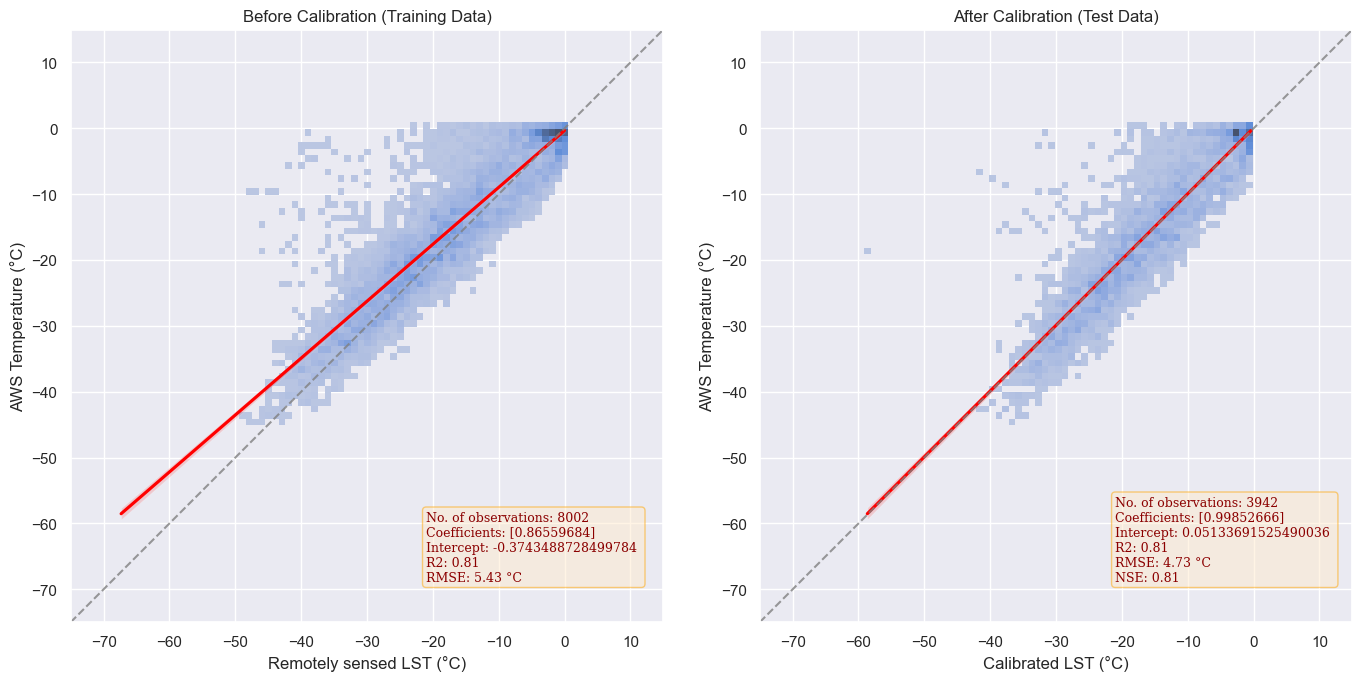

--- Results for station KAN_U ---


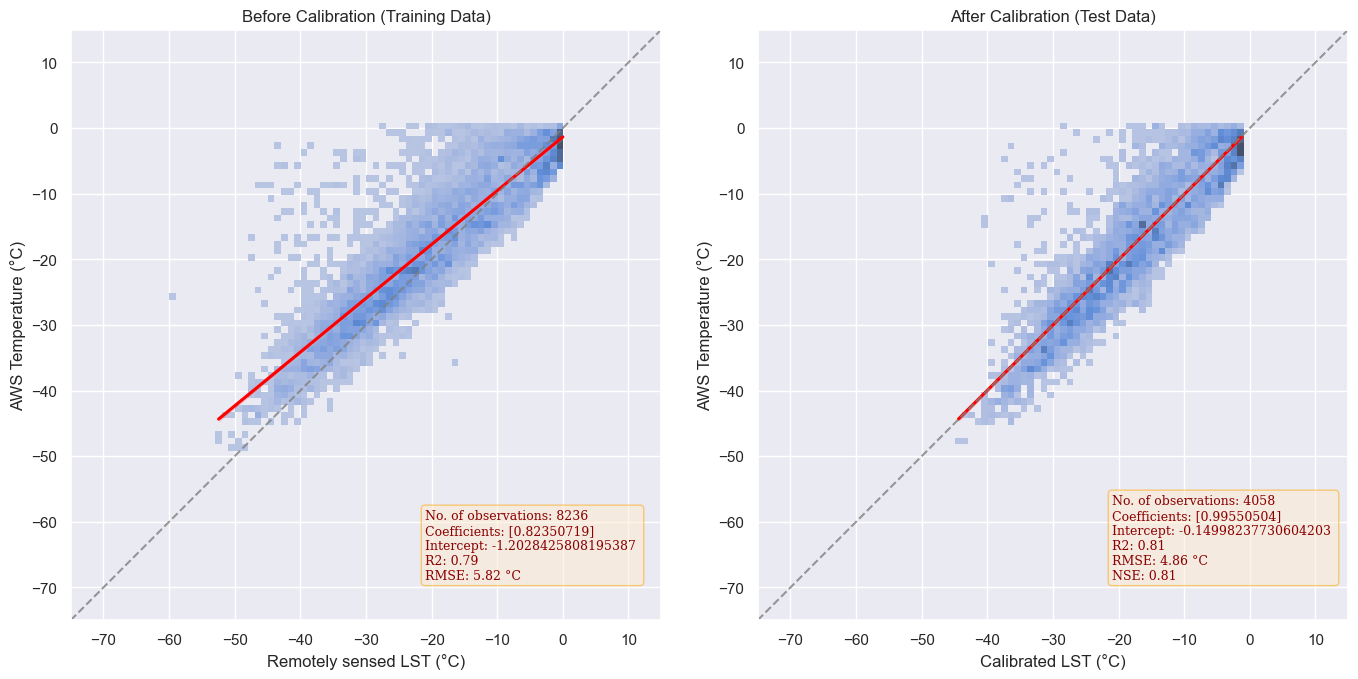

--- Results for station KPC_L ---


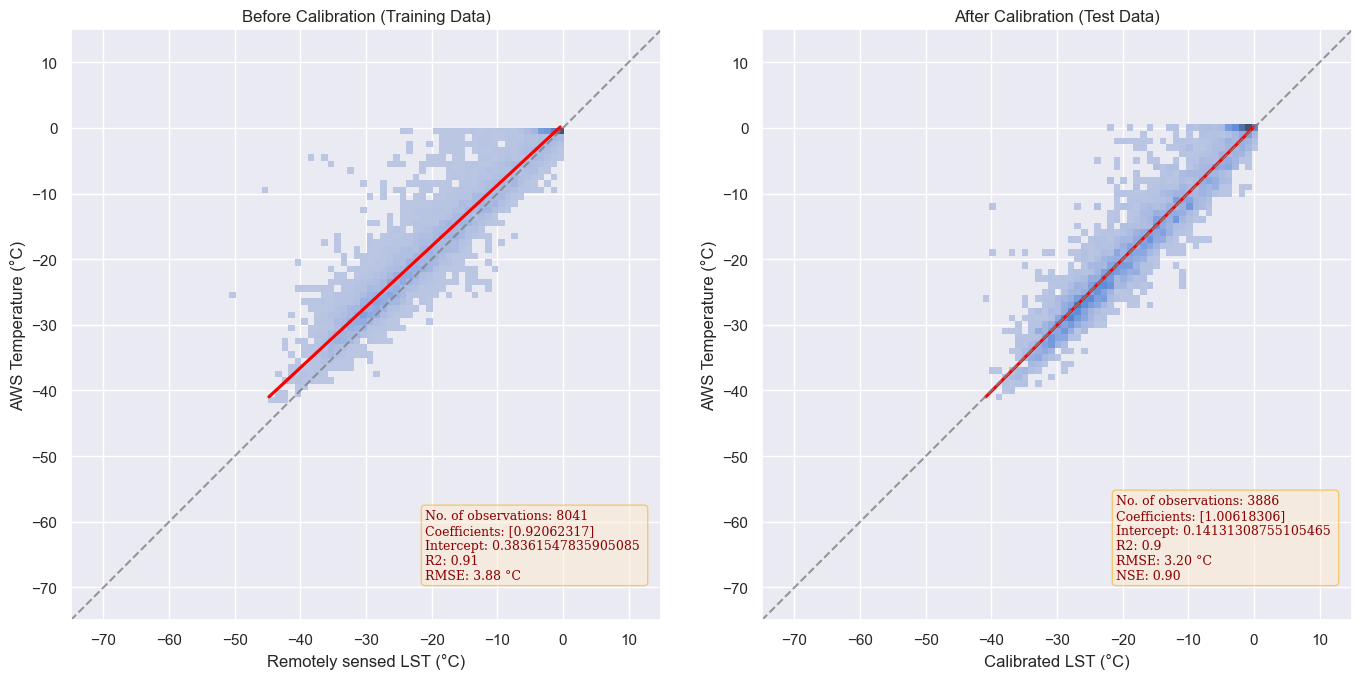

--- Results for station KPC_U ---


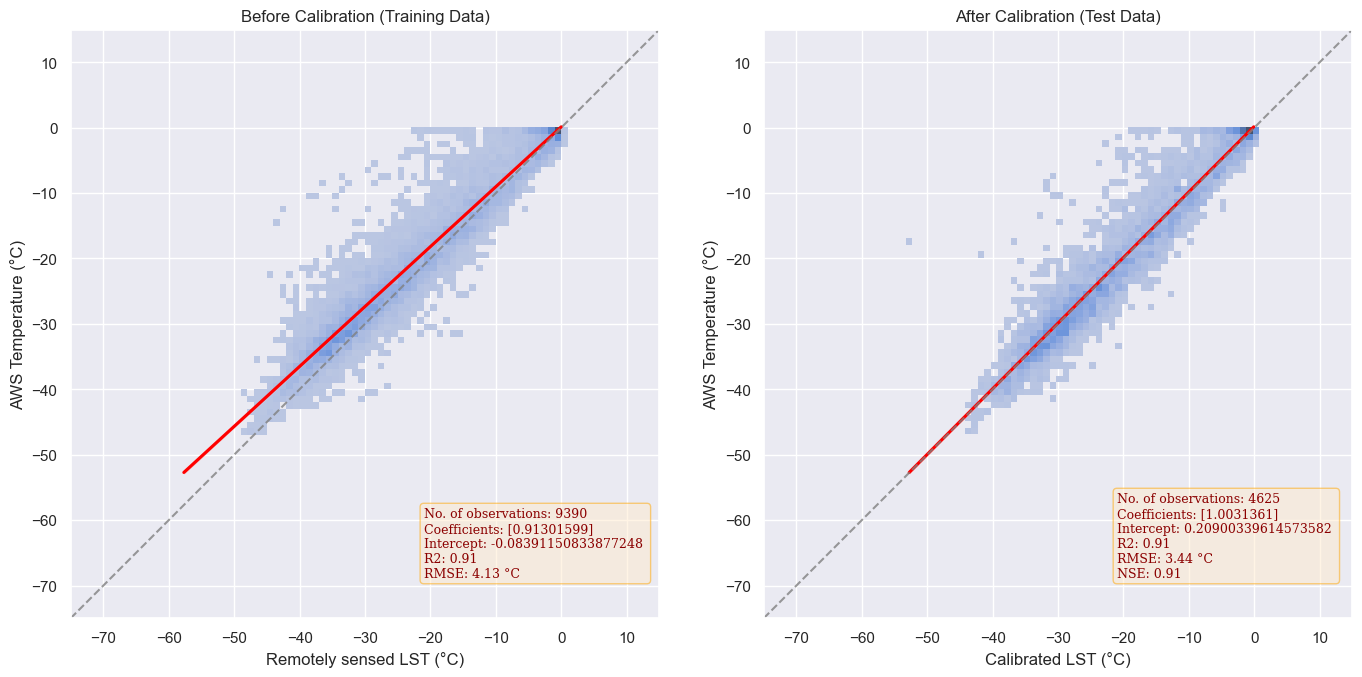

--- Results for station NAE ---


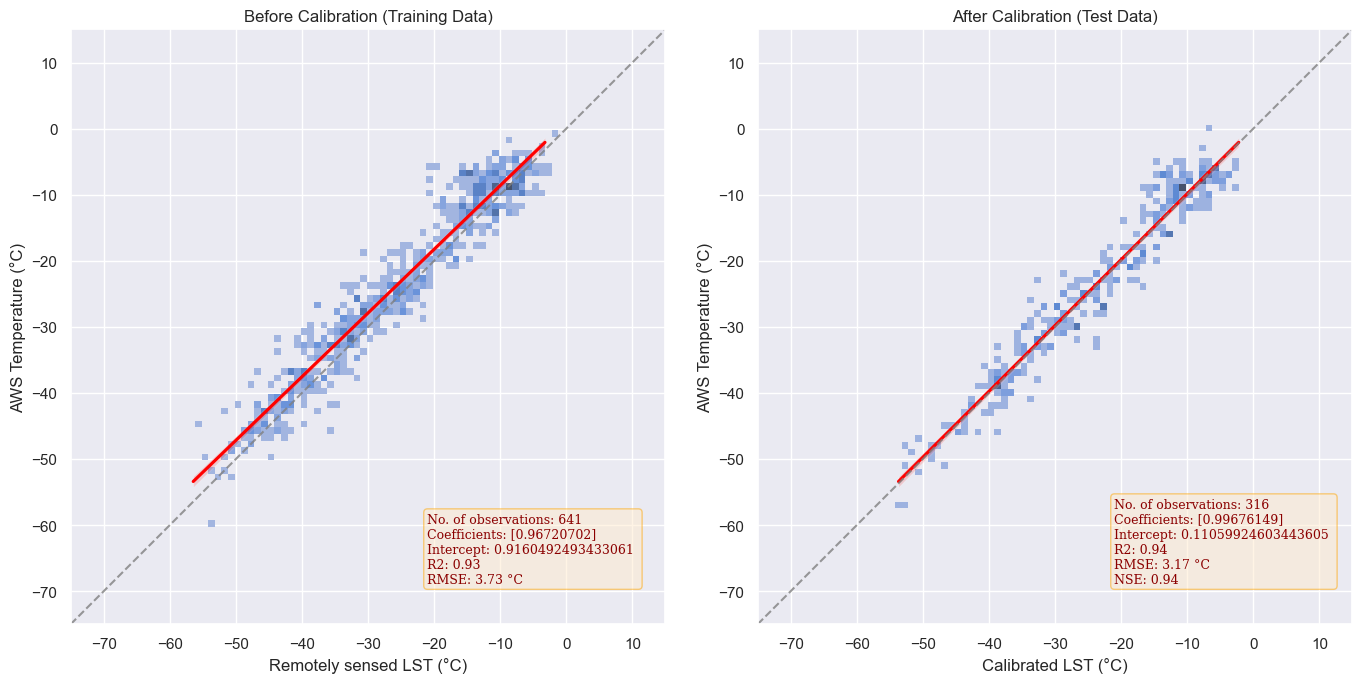

--- Results for station NAU ---


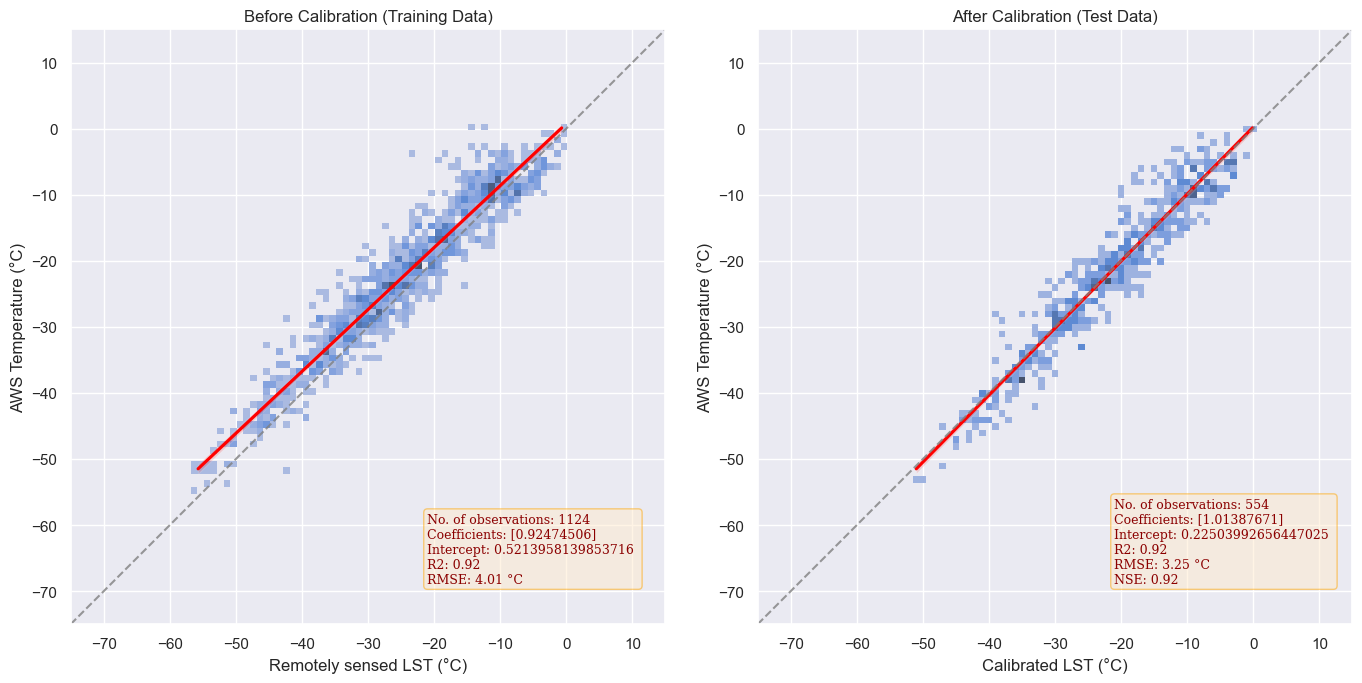

--- Results for station NEM ---


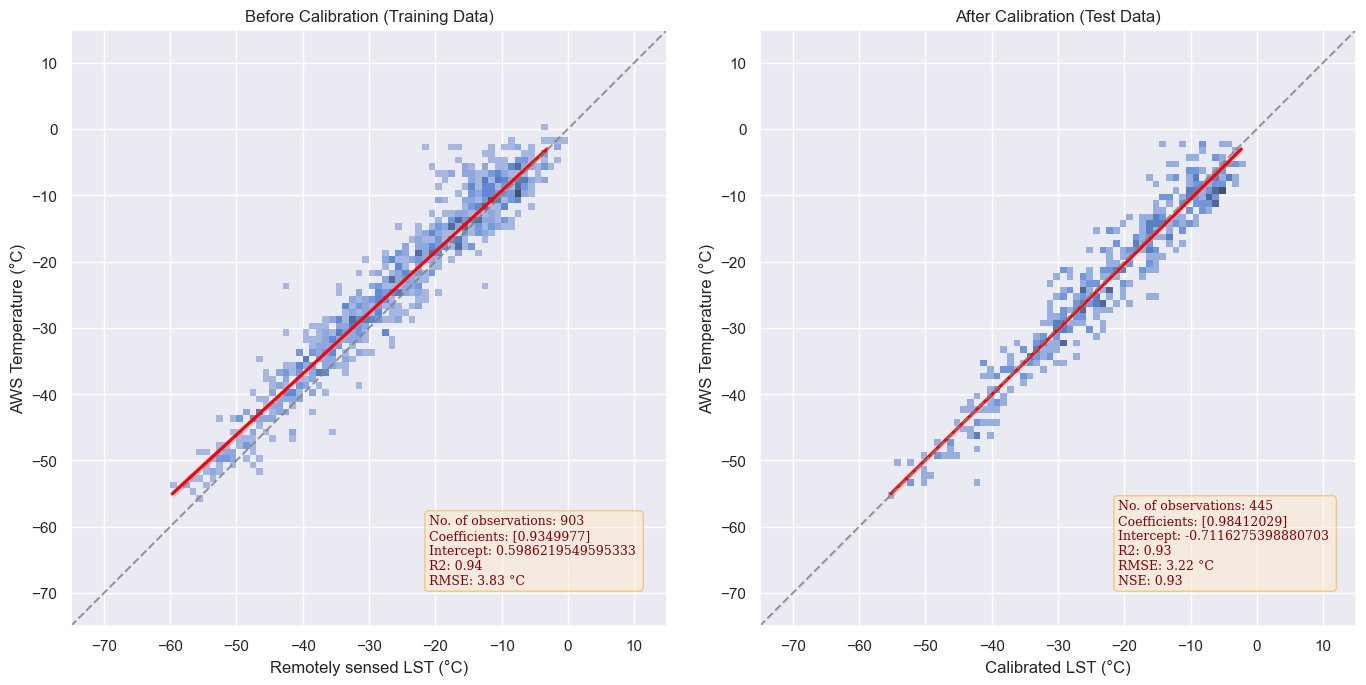

--- Results for station NSE ---


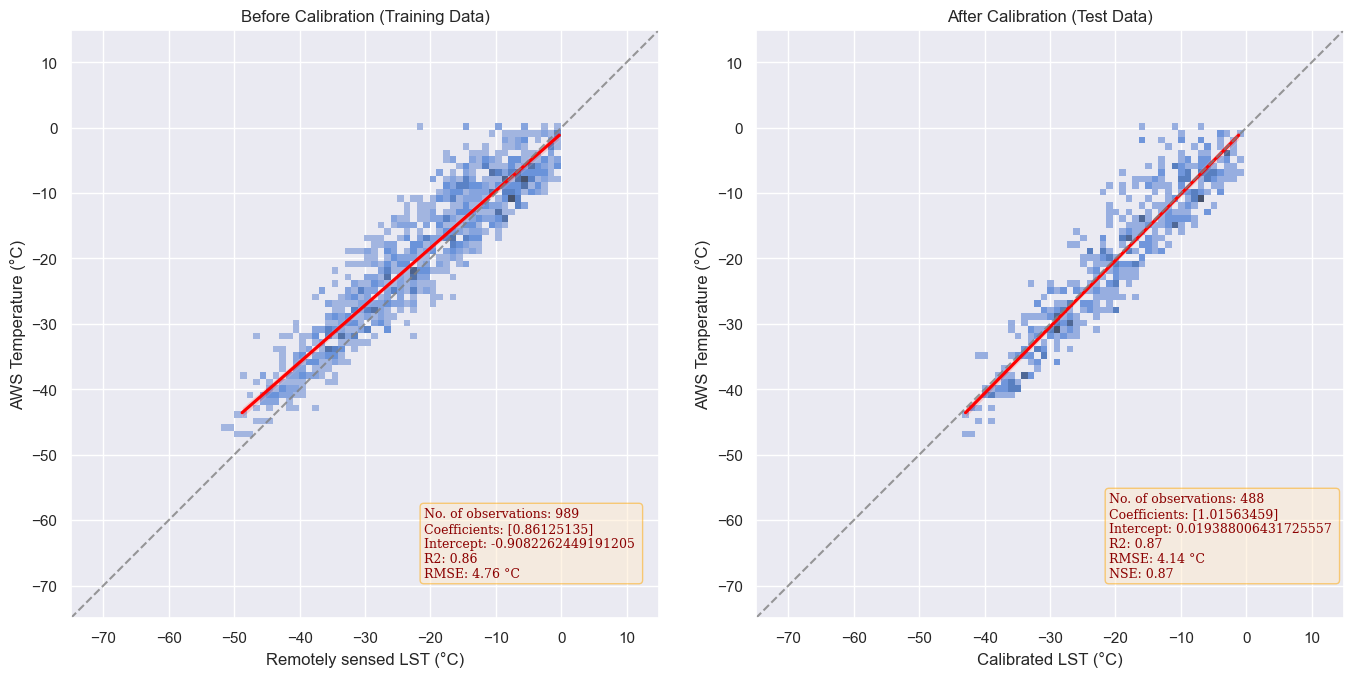

--- Results for station SCO_U ---


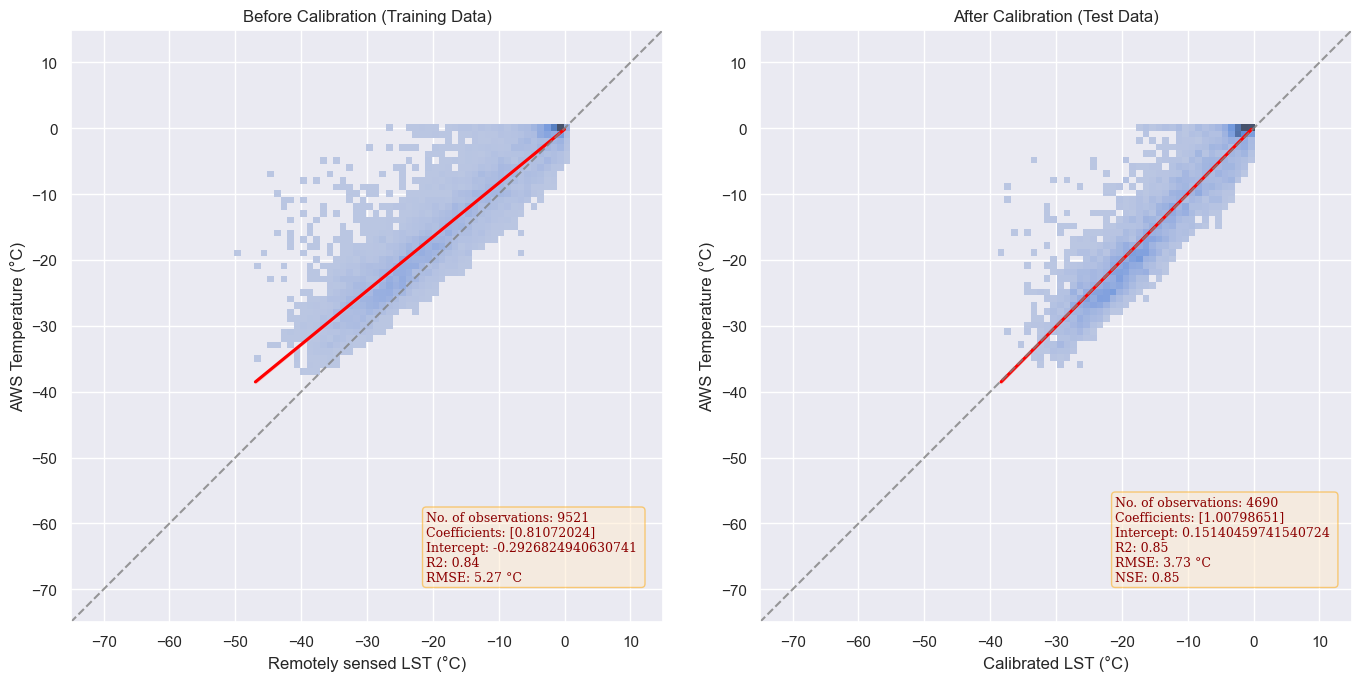

--- Results for station SDL ---


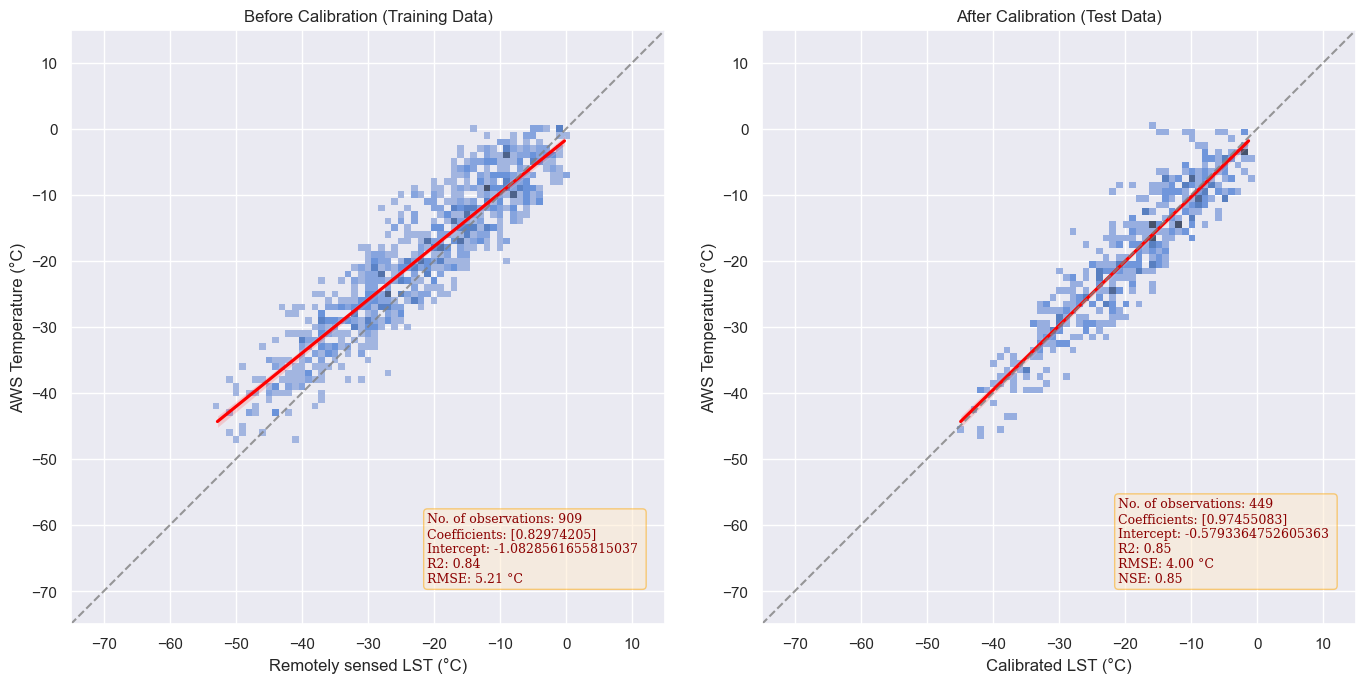

--- Results for station SDM ---


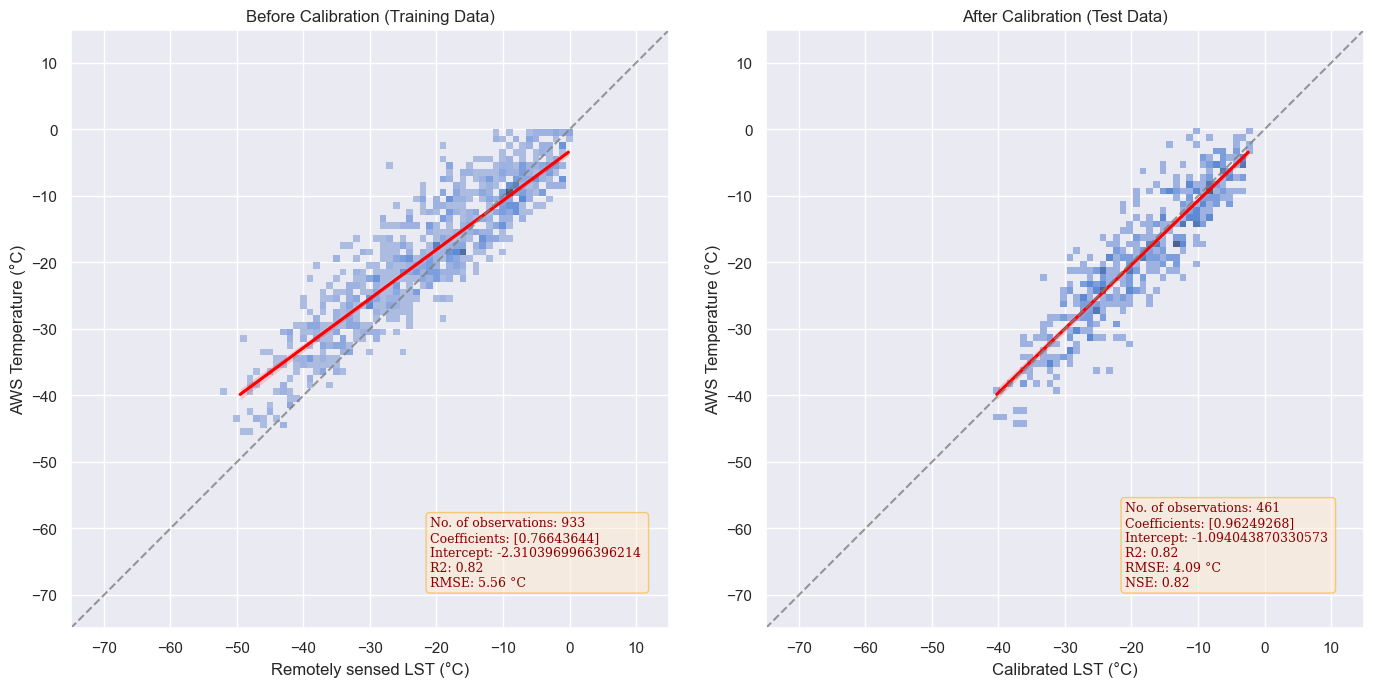

--- Results for station SWC ---


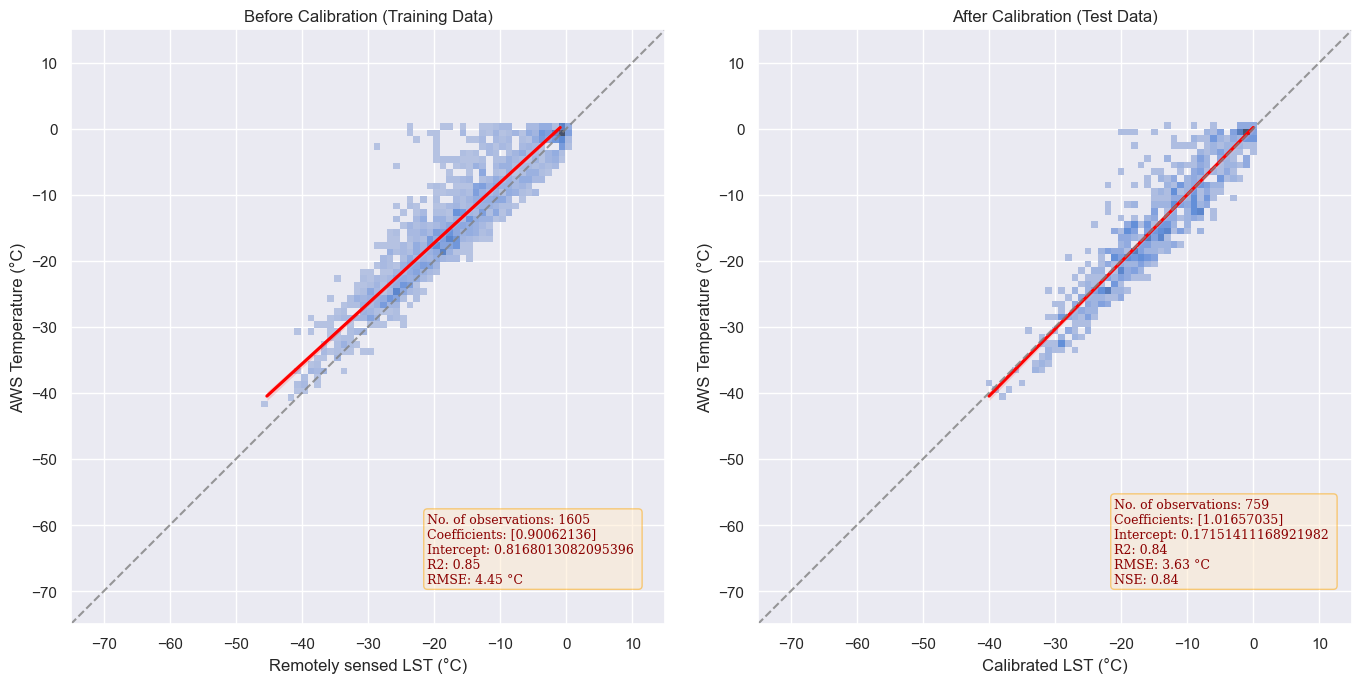

--- Results for station THU_L ---


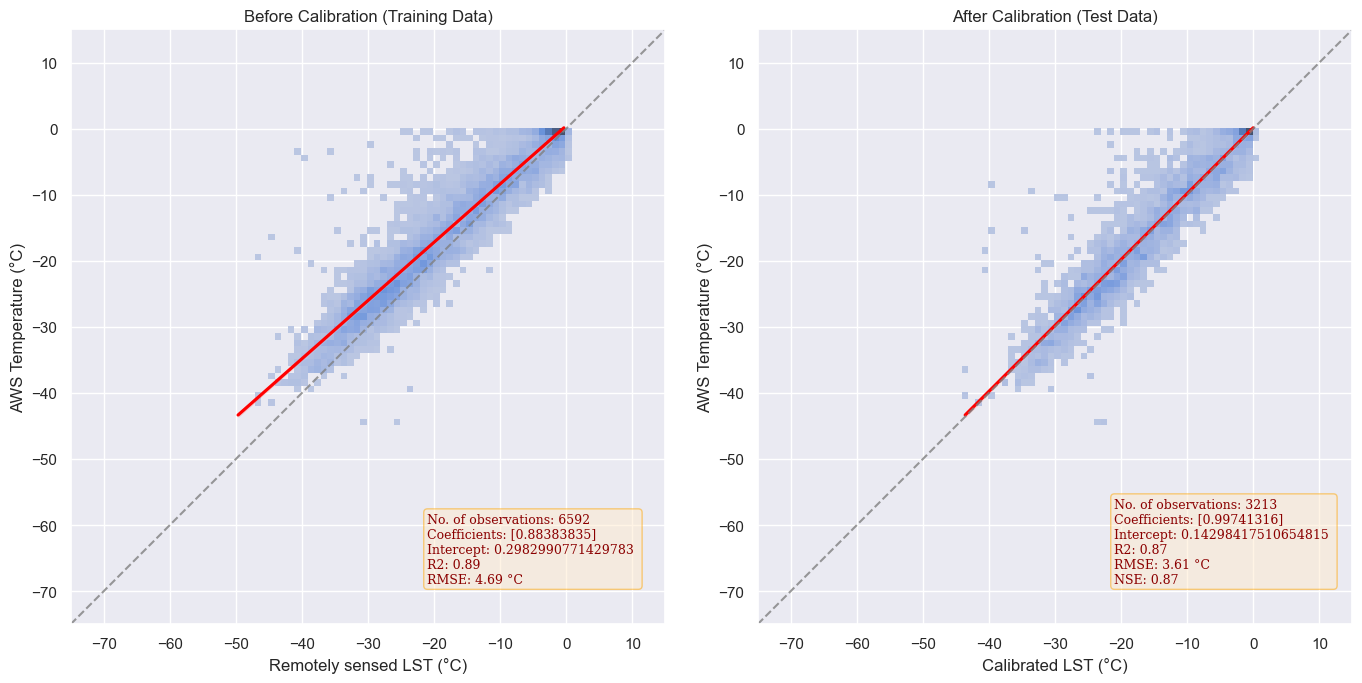

--- Results for station THU_L2 ---


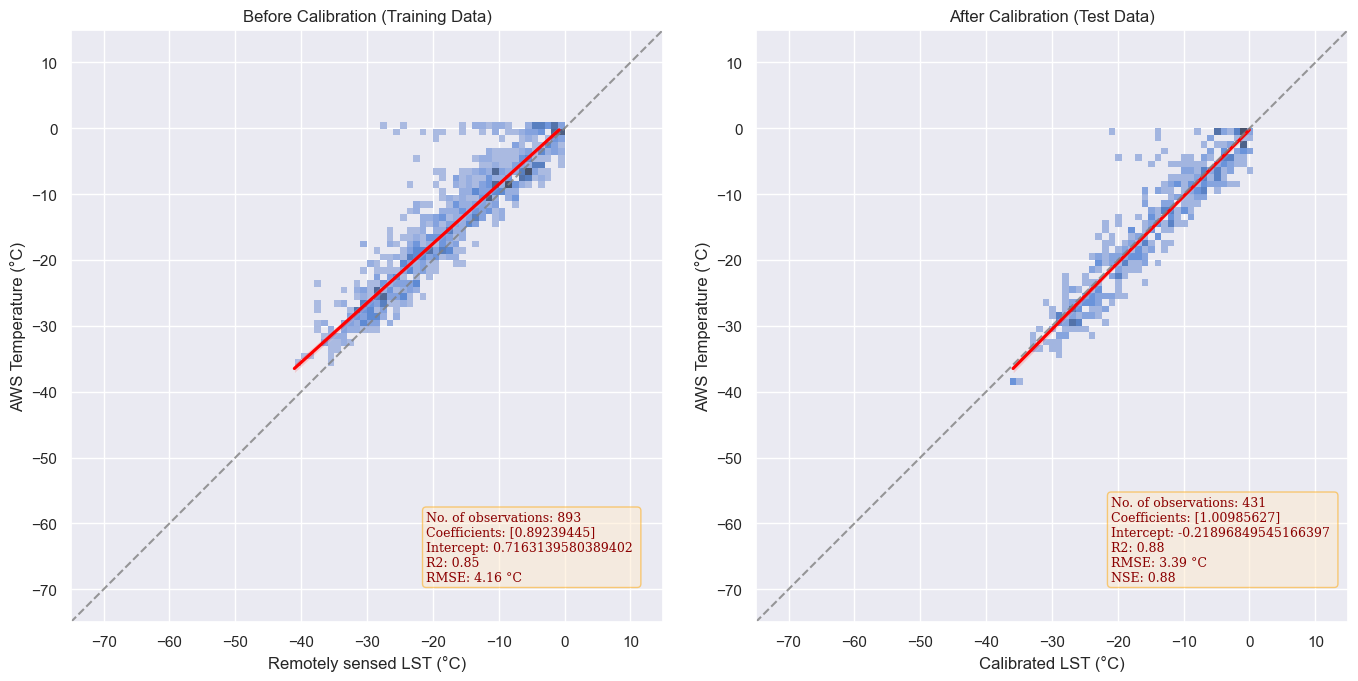

--- Results for station THU_U ---


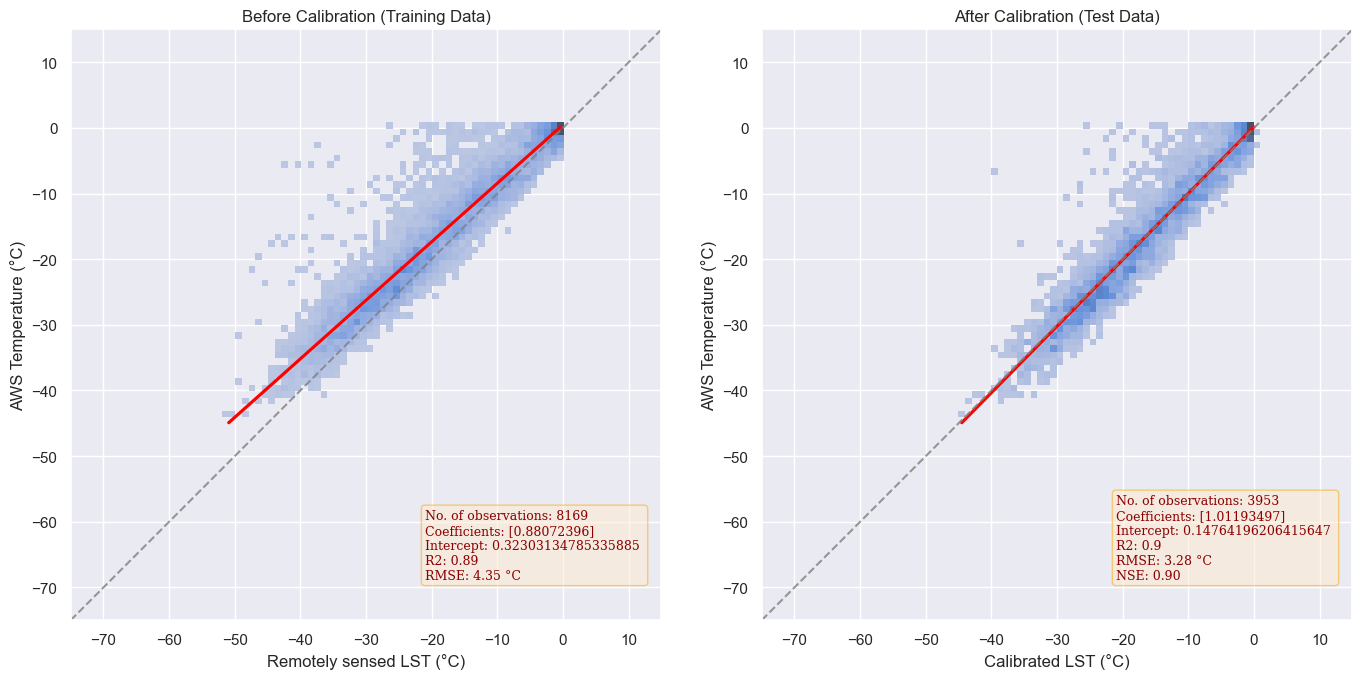

--- Results for station TUN ---


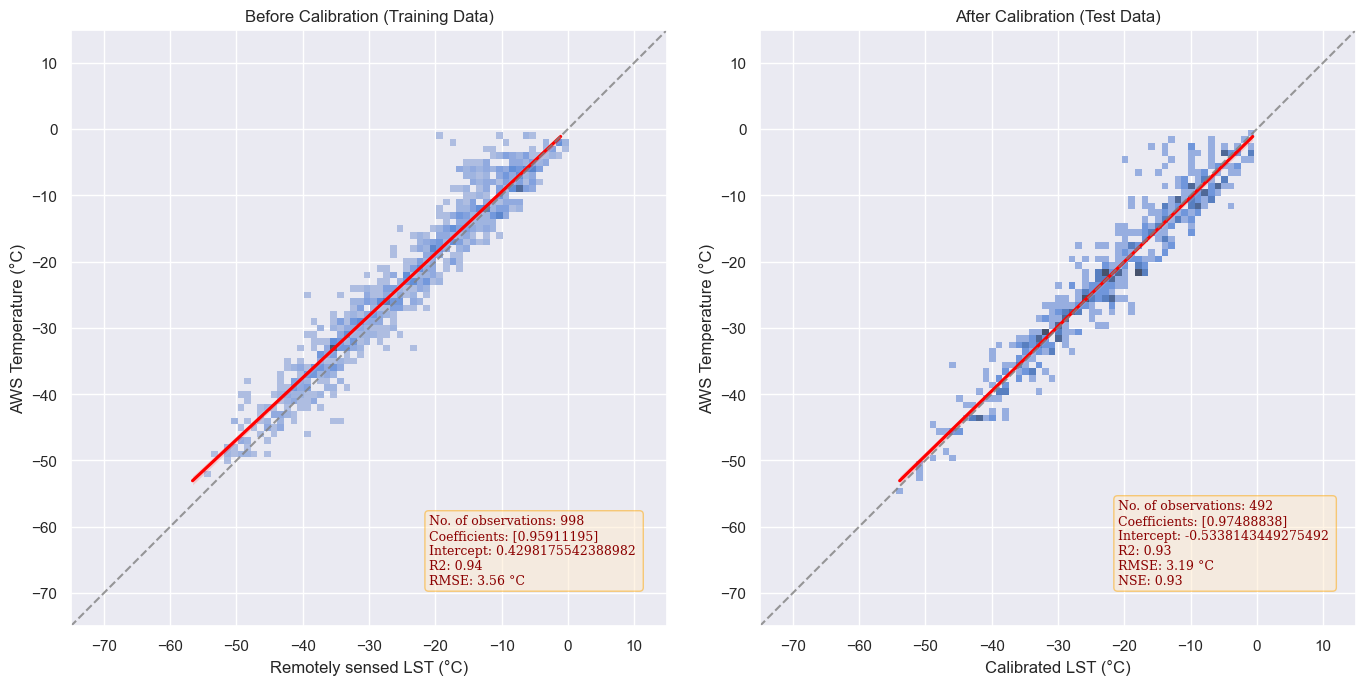

--- Results for station UPE_U ---


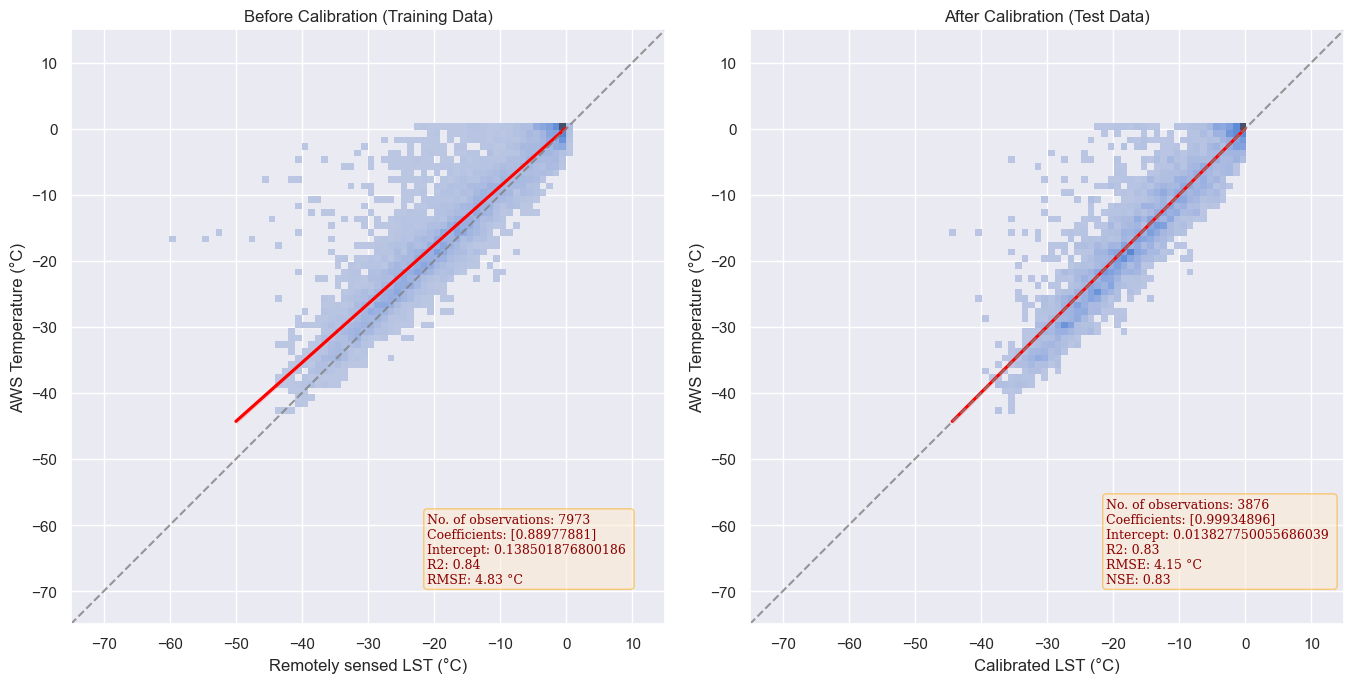

--- Results for station WEG_L ---


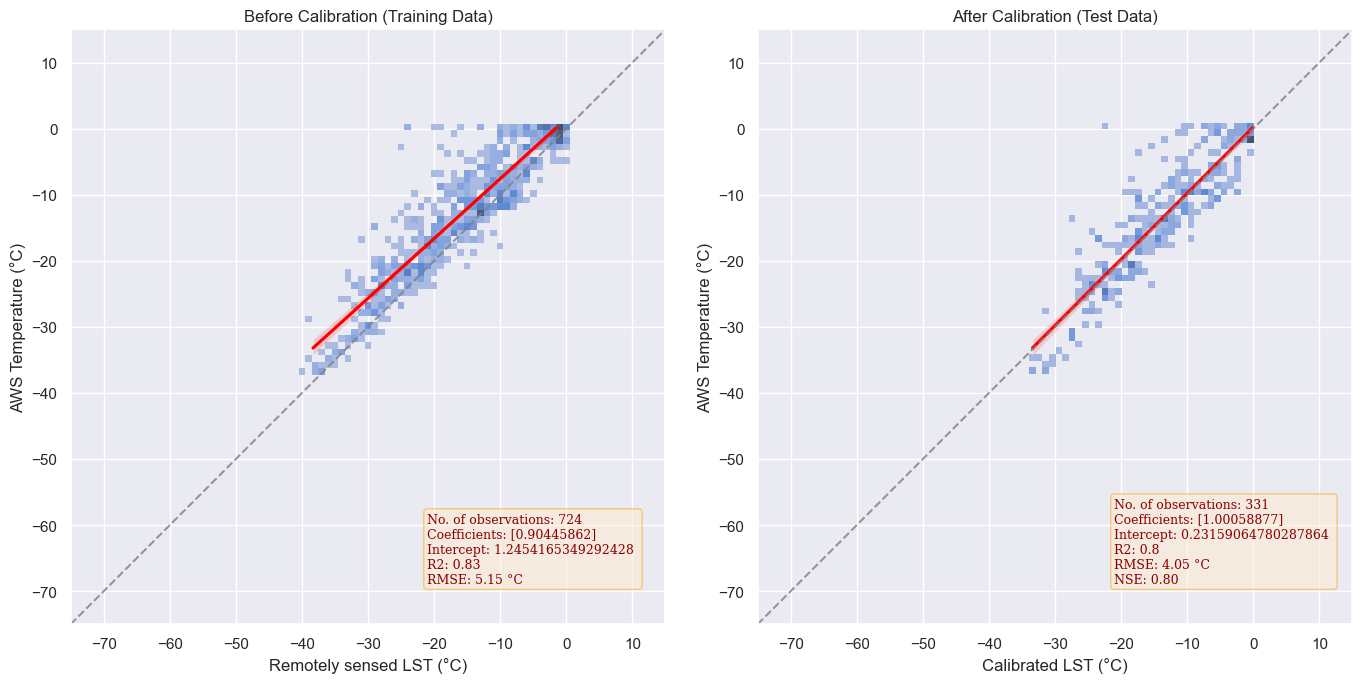

In [19]:
stations = aws_data['aws'].unique()

dfs = [df_modd1, df_modn1, df_mydd1, df_mydn1, df_jaxa_a, df_jaxa_d, df_viirs_day, df_viirs_night]
labels = ["MOD_Terra_DAY", "MOD_Terra_NIGHT", "MYD_Aqua_DAY", "MYD_Aqua_NIGHT", "JAXA_A", "JAXA_D", "VIIRS_DAY", "VIIRS_NIGHT"]

all_data = pd.concat(dfs, keys=labels, names=['Satellite', 'RowID']).reset_index(level='Satellite').reset_index(drop=True)

# Calculate NSE for every station in order to compare the goodness of fit across stations
def nse(df):
    """Nash-Sutcliffe Efficiency (NSE) as per `Nash and Sutcliffe, 1970
    <https://doi.org/10.1016/0022-1694(70)90255-6>`_.
    :Calculation Details:
        .. math::
           E_{\\text{NSE}} = 1 - \\frac{\\sum_{i=1}^{N}[e_{i}-s_{i}]^2}
           {\\sum_{i=1}^{N}[e_{i}-\\mu(e)]^2}
        where *N* is the length of the *simulations* and *evaluation*
        periods, *e* is the *evaluation* series, *s* is (one of) the
        *simulations* series, and *μ* is the arithmetic mean.
    https://github.com/ThibHlln/hydroeval/tree/v0.1.0
    Thibault Hallouin, 2021. hydroeval: an evaluator for streamflow time series in Python. https://doi.org/10.5281/zenodo.4709652        
    """
    obs = df['t_surf'].to_numpy(dtype=np.float64)
    pred = df['lst_calibrated'].to_numpy(dtype=np.float64)
    
    nse_ = 1 - (
            np.sum((obs - pred) ** 2, axis=0, dtype=np.float64)
            / np.sum((obs - np.mean(obs)) ** 2, dtype=np.float64)
    )
    return nse_


def split_mod_viz(df):

    df = df[df['est_temp'] <= 0]

    # Split data into training and testing sets (2/3 training, 1/3 testing)
    train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

    # Regression model fit and prediction
    model = LinearRegression()
    model.fit(train_df[['est_temp']], train_df['t_surf'])
    model.predict(test_df[['est_temp']])
    r2_train = round(model.score(train_df[['est_temp']], train_df['t_surf']), 2)

    # Apply calibration to test dataset
    test_df['lst_calibrated'] = test_df['est_temp'] * model.coef_[0] + model.intercept_
    test_df = test_df[test_df['lst_calibrated'] <= 0]

    # Reveal coefficients of the calibrated model
    model2 = LinearRegression()
    model2.fit(test_df[['lst_calibrated']], test_df['t_surf'])
    r2_test = round(model2.score(test_df[['lst_calibrated']], test_df['t_surf']), 2)

    # Calculate RMSE and NSE of the calibration results
    rmse_before = ((test_df['est_temp'] - test_df['t_surf']) ** 2).mean() ** 0.5
    rmse_after = ((test_df['lst_calibrated'] - test_df['t_surf']) ** 2).mean() ** 0.5
    nse_after = round(nse(test_df),2)

    s1 = f'No. of observations: {len(train_df)} \nCoefficients: {model.coef_} \nIntercept: {model.intercept_} \nR2: {r2_train} \nRMSE: {rmse_before:.2f} °C'
    s2 = f'No. of observations: {len(test_df)} \nCoefficients: {model2.coef_} \nIntercept: {model2.intercept_} \nR2: {r2_test} \nRMSE: {rmse_after:.2f} °C \nNSE: {nse_after:.2f}'

    ### GRAPHICAL VISUALIZATION ###
    # Create comparison plot of original vs calibrated values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    # Add 1:1 reference line 
    min_val = -75
    max_val = 15

    # 
    font = {'family': 'serif',
            'color':  'darkred',
            'weight': 'normal',
            'size': 9,
            }
    
    bbox = dict(
        boxstyle='round', 
        fc='blanchedalmond', 
        ec='orange', 
        alpha=0.5)

    # 2d HISTOGRAM PLOTS
    # Original est_temp plot
    sns.histplot(ax=ax1, data=train_df, x='est_temp', y='t_surf', bins=60, discrete=True)
    sns.regplot(ax=ax1, data=test_df, x='est_temp', y='t_surf', scatter=False, color='red')
    ax1.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    ax1.text(0.6, 0.07, s1, fontdict=font, bbox=bbox, transform=ax1.transAxes, horizontalalignment='left')
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)
    ax1.set_xlabel('Remotely sensed LST (°C)')
    ax1.set_ylabel('AWS Temperature (°C)')
    ax1.set_title('Before Calibration (Training Data)')
    ax1.set_aspect('equal')

    # Calibrated est_temp plot
    sns.histplot(ax=ax2, data=test_df, x='lst_calibrated', y='t_surf', bins=60, discrete=True)
    sns.regplot(ax=ax2, data=test_df, x='lst_calibrated', y='t_surf', scatter=False, color='red')
    ax2.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    ax2.text(0.6, 0.07, s2, fontdict=font, bbox=bbox, transform=ax2.transAxes, horizontalalignment='left')
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)
    ax2.set_xlabel('Calibrated LST (°C)')
    ax2.set_ylabel('AWS Temperature (°C)')
    ax2.set_title('After Calibration (Test Data)')
    ax2.set_aspect('equal')
    plt.tight_layout()

    # Save the graph as PNG
    # fig.savefig(f'./Graphs/Calibration_Stations/Calibration_{station}.png', dpi=300)
    plt.show()
    plt.close(fig)


###### FOR EACH Station and ONE SENSOR
for station in stations:
    print(f"--- Results for station {station} ---")
    all_data_station = all_data[all_data['aws'] == station]
    split_mod_viz(all_data_station)



In [46]:
# COEFFICIENTS AND NSE FOR EACH STATION AND ALL SENSORS AS TABLE
dfs = [df_modd1, df_modn1, df_mydd1, df_mydn1, df_jaxa_a, df_jaxa_d, df_viirs_day, df_viirs_night]
labels = ["MOD_Terra_DAY", "MOD_Terra_NIGHT", "MYD_Aqua_DAY", "MYD_Aqua_NIGHT", "JAXA_A", "JAXA_D", "VIIRS_DAY", "VIIRS_NIGHT"]

all_data = pd.concat(dfs, keys=labels, names=['Satellite', 'RowID']).reset_index(level='Satellite').reset_index(drop=True)

stations = aws_data['aws'].unique() ####### OBS ######## 

# Calculate NSE for every station in order to compare the goodness of fit across stations
def nse(df):
    """Nash-Sutcliffe Efficiency (NSE) as per `Nash and Sutcliffe, 1970
    <https://doi.org/10.1016/0022-1694(70)90255-6>`_.
    :Calculation Details:
        .. math::
           E_{\\text{NSE}} = 1 - \\frac{\\sum_{i=1}^{N}[e_{i}-s_{i}]^2}
           {\\sum_{i=1}^{N}[e_{i}-\\mu(e)]^2}
        where *N* is the length of the *simulations* and *evaluation*
        periods, *e* is the *evaluation* series, *s* is (one of) the
        *simulations* series, and *μ* is the arithmetic mean.
    https://github.com/ThibHlln/hydroeval/tree/v0.1.0
    Thibault Hallouin, 2021. hydroeval: an evaluator for streamflow time series in Python. https://doi.org/10.5281/zenodo.4709652        
    """
    obs = df['t_surf'].to_numpy(dtype=np.float64)
    pred = df['lst_calibrated'].to_numpy(dtype=np.float64)
    
    nse_ = 1 - (
            np.sum((obs - pred) ** 2, axis=0, dtype=np.float64)
            / np.sum((obs - np.mean(obs)) ** 2, dtype=np.float64)
    )
    return nse_


def split_mod_df(df):

    df = df[df['est_temp'] <= 0]

    # Split data into training and testing sets (2/3 training, 1/3 testing)
    train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

    # Regression model fit and prediction
    model = LinearRegression()
    model.fit(train_df[['est_temp']], train_df['t_surf'])
    model.predict(test_df[['est_temp']])
    r2_train = round(model.score(train_df[['est_temp']], train_df['t_surf']), 2)

    # Apply calibration to test dataset
    test_df['lst_calibrated'] = test_df['est_temp'] * model.coef_[0] + model.intercept_
    test_df = test_df[test_df['lst_calibrated'] <= 0]

    # Reveal coefficients of the calibrated model
    model2 = LinearRegression()
    model2.fit(test_df[['lst_calibrated']], test_df['t_surf'])
    r2_test = round(model2.score(test_df[['lst_calibrated']], test_df['t_surf']), 2)

    # Calculate RMSE and NSE of the calibration results
    rmse_before = ((test_df['est_temp'] - test_df['t_surf']) ** 2).mean() ** 0.5
    rmse_after = ((test_df['lst_calibrated'] - test_df['t_surf']) ** 2).mean() ** 0.5
    nse_after = round(nse(test_df),2)

    return {
        "n_obs": len(df),
        "coef": model.coef_[0],
        "intercept": model.intercept_,
        'R-squared': r2_train,
        'rmse_before': rmse_before,
        "coef_calibrated": model2.coef_[0],
        "intercept_corrected": model2.intercept_,
        "R-squared_after": r2_test,
        'rmse_after': rmse_after,
        "NSE": nse_after
        }


##### FOR EACH Station and all sensors

results_pr_staton = []

for station in stations:
    all_data_station = all_data[all_data['aws'] == station]
    results_pr_staton.append(split_mod_df(all_data_station))
    results_pr_staton[-1]['Station'] = station

df_results_station = pd.DataFrame(results_pr_staton)
df_results_station.sort_values(by='NSE', ascending=False, inplace=True)
# df_results_station.to_csv('./Data/PROMICE/output/Calibration_Stations/Coefficients_PROMICE_Stations_new.csv', index=False)

# # count observations per class "aws" in the dataset all_data
# obs_counts = all_data['aws'].value_counts().reset_index()
# obs_counts.columns = ['aws', 'n_obs']
# obs_counts

print(df_results_station)

selected_stations = df_results_station[df_results_station['R-squared_after'] >= 0.8]['Station'].tolist()

    n_obs      coef  intercept  R-squared  rmse_before  coef_calibrated  \
0    5514  0.916781   0.352770       0.92     4.506266         1.002284   
1    7425  0.924775  -0.820098       0.92     4.172472         1.000122   
6   14015  0.913016  -0.083912       0.91     4.127194         1.003136   
9   12193  0.880724   0.323031       0.89     4.348483         1.011935   
5   12002  0.920623   0.383615       0.91     3.877715         1.006183   
8    9839  0.883838   0.298299       0.89     4.688100         0.997413   
7   14211  0.810720  -0.292682       0.84     5.274127         1.007987   
10  11900  0.889779   0.138502       0.84     4.825876         0.999349   
2   12050  0.828648   0.337783       0.81     5.070313         1.027937   
3   11944  0.865597  -0.374349       0.81     5.426764         0.998527   
4   12294  0.823507  -1.202843       0.79     5.818505         0.995505   

    intercept_corrected  R-squared_after  rmse_after   NSE Station  
0              0.120529       

### Extract coefficients for all possible satellite combinations. 

In [8]:
dfs = [df_modd1, df_modn1, df_mydd1, df_mydn1, df_viirs_day, df_viirs_night, df_jaxa_a, df_jaxa_d]
labels = ["MOD_Terra_DAY", "MOD_Terra_NIGHT", "MYD_Aqua_DAY", "MYD_Aqua_NIGHT", "VIIRS_DAY", "VIIRS_NIGHT", "JAXA_A", "JAXA_D"]


def split_mod_viz(df):

    df = df[df['est_temp'] <= 0]

    # Split data into training and testing sets (2/3 training, 1/3 testing)
    train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

    # Regression model fit and prediction
    model = LinearRegression()
    model.fit(train_df[['est_temp']], train_df['t_surf'])
    model.predict(test_df[['est_temp']])
    r2_train = round(model.score(train_df[['est_temp']], train_df['t_surf']), 2)

    # Apply calibration to test dataset
    test_df['lst_calibrated'] = test_df['est_temp'] * model.coef_[0] + model.intercept_
    test_df = test_df[test_df['lst_calibrated'] <= 0]

    # Reveal coefficients of the calibrated model
    model2 = LinearRegression()
    model2.fit(test_df[['lst_calibrated']], test_df['t_surf'])
    r2_test = round(model2.score(test_df[['lst_calibrated']], test_df['t_surf']), 2)

    return {
        "n_obs": len(df),
        "coef_before": model.coef_[0],
        "intercept_before": model.intercept_,
        "R-squared_before": r2_train,
        "rmse_before": ((test_df['est_temp'] - test_df['t_surf']) ** 2).mean() ** 0.5,
        "coef_calibrated": model2.coef_[0],
        "intercept_corrected": model2.intercept_,
        "R-squared_after": r2_test,
        "rmse_after": ((test_df['est_temp'] * model.coef_[0] + model.intercept_ - test_df['t_surf']) ** 2).mean() ** 0.5
        }


#### CREATE DATASHEET FOR ALL COMBINATIONS
results = [] 

for r in range(1, len(dfs) + 1):
    for idxs in itertools.combinations(range(len(dfs)), r):
        combo_labels = [labels[i] for i in idxs]
        combo_dfs = [dfs[i] for i in idxs]

        # Merge all selected datasets
        # Assuming they can be merged on a common key (e.g. "pixel_id" or time)
        df_merged = pd.concat(combo_dfs)

        # Run regression
        result = split_mod_viz(df_merged)
        result["Combination"] = " + ".join(combo_labels)
        results.append(result)

# --- Create a summary table ---
df_results = pd.DataFrame(results)
print(df_results.head())

df_results.to_csv('./Data/SKL_Coefficients_Ice_comb_allestationer_ci.csv', index=False)



# For large amounts of data, consider a 2d hist, kernel density or vaex plot
# https://seaborn.pydata.org/generated/seaborn.kdeplot.html
# https://seaborn.pydata.org/generated/seaborn.histplot.html
# https://vaex.io/docs/index.html


   n_obs  coef_before  intercept_before  \
0  21873     0.841338         -1.488118   
1  13745     0.886062          1.855084   
2  22828     0.880496         -1.106138   
3  13534     0.921282          2.873507   
4  33312     0.925288          0.271427   

                  confidence_interval_before  R-squared_before  rmse_before  \
0    (-8.96249559870896, 10.645170696559626)              0.85     5.001956   
1  (-11.819626747193922, 13.591750912488582)              0.88     6.482494   
2    (-6.502875240122256, 8.263867033232808)              0.93     3.767026   
3  (-11.451304413758624, 13.293867683084521)              0.90     6.312544   
4    (-7.374587755755555, 9.225163543037748)              0.87     4.234630   

   coef_calibrated  intercept_corrected  R-squared_after  rmse_after  \
0         1.003663             0.042348             0.85    4.331065   
1         1.014956             0.572837             0.85    4.394022   
2         0.996847            -0.034789           

In [54]:
sheet = pd.read_csv('./Data/Availability_pattern_sensors.csv')
patterns = pd.DataFrame(sheet)

coef_ice = pd.read_csv('./Data/SKL_Coefficients_Ice_comb_allestationer.csv')

lookup_ice = coef_ice.join(patterns.set_index('Sensor_Combo'), on ='Combination').set_index('ID').sort_index().iloc[:,:10]

lookup_ice.to_csv('./Data/SKL_Lookup_Ice_alle.csv')

### Significance test of the coefficients 25 vs. 11 stations
Test whether the coefficients of the analysis on the larger dataset (25 stations that passed with R2 of >= 0.8) and smaller dataset (11 stations with R2 >= 0.8 for MOD_DAY) vary significantly for the sensor combinations. 


It turns out that 53 of 255 combinations actually have a not-overlapping confidence interval, -> are significantly different between the large dataset and the smaller subset with only 11 stations. 

In [48]:
# # Perform the same operation as in the cell above, just using the statsmodels.api smf and smf.ols function. Adjust the code so it also calculates confidence intervals and add them to the dictionary.
# import statsmodels.api as sm
# import statsmodels.formula.api as smf

# def split_mod_viz_statsmodels(df):
#     df = df[df['est_temp'] <= 0]

#     # Split data into training and testing sets (2/3 training, 1/3 testing)
#     train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

#     # Fit the OLS model using statsmodels
#     model = smf.ols('t_surf ~ est_temp', data=train_df).fit()

#     # Get predictions and R-squared for the training set
#     train_predictions = model.predict(train_df)
#     r2_train = round(model.rsquared, 2)

#     # Apply calibration to test dataset
#     test_df['lst_calibrated'] = test_df['est_temp'] * model.params['est_temp'] + model.params['Intercept']
#     test_df = test_df[test_df['lst_calibrated'] <= 0]

#     # Fit a new OLS model on the calibrated data
#     model_calibrated = smf.ols('t_surf ~ lst_calibrated', data=test_df).fit()
#     r2_test = round(model_calibrated.rsquared, 2)

#     # Calculate RMSE for before and after calibration
#     rmse_before = ((test_df['est_temp'] - test_df['t_surf']) ** 2).mean() ** 0.5
#     rmse_after = ((test_df['lst_calibrated'] - test_df['t_surf']) ** 2).mean() ** 0.5

#     return {
#         "n_obs": len(df),
#         "coef_before": model.params['est_temp'],
#         "intercept_before": model.params['Intercept'],
#         "R-squared_before": r2_train,
#         "rmse_before": rmse_before,
#         "coef_calibrated": model_calibrated.params['lst_calibrated'],
#         "intercept_corrected": model_calibrated.params['Intercept'],
#         "R-squared_after": r2_test,
#         "rmse_after": rmse_after,
#         "ci_coef_before": model.conf_int().loc['est_temp'].tolist(),
#         "ci_intercept_before": model.conf_int().loc['Intercept'].tolist(),
#         "ci_coef_calibrated": model_calibrated.conf_int().loc['lst_calibrated'].tolist(),
#         "ci_intercept_calibrated": model_calibrated.conf_int().loc['Intercept'].tolist()
#     }

# #### CREATE DATASHEET FOR ALL COMBINATIONS
# results = [] 

# for r in range(1, len(dfs) + 1):
#     for idxs in itertools.combinations(range(len(dfs)), r):
#         combo_labels = [labels[i] for i in idxs]
#         combo_dfs = [dfs[i] for i in idxs]

#         # Merge all selected datasets
#         # Assuming they can be merged on a common key (e.g. "pixel_id" or time)
#         df_merged = pd.concat(combo_dfs)

#         # Run regression
#         result = split_mod_viz_statsmodels(df_merged)
#         result["Combination"] = " + ".join(combo_labels)
#         results.append(result)

# # --- Create a summary table ---
# df_results = pd.DataFrame(results)
# print(df_results.head())

# df_results.to_csv('./Data/SKL_Coefficients_Ice_comb_11_ci.csv', index=False)

   n_obs  coef_before  intercept_before  R-squared_before  rmse_before  \
0  21873     0.841338         -1.488118              0.85     5.001956   
1  13745     0.886062          1.855084              0.88     6.482494   
2  22735     0.880110         -1.098228              0.93     3.696512   
3  13487     0.923323          2.886125              0.90     6.427194   
4   1546     0.903988          1.050496              0.83     4.136250   

   coef_calibrated  intercept_corrected  R-squared_after  rmse_after  \
0         1.003663             0.042348             0.85    4.331065   
1         1.014956             0.572837             0.85    4.394022   
2         0.998104            -0.058041             0.93    3.152432   
3         1.036075             0.995082             0.88    4.113544   
4         1.050447             0.600376             0.82    3.457878   

                             ci_coef_before  \
0  [0.8356523863494799, 0.8470227115011847]   
1  [0.8792636434357479, 0.89

In [52]:
# # For every unique combination in the column "Combination" in the tables SKL_Coefficients_Ice_comb_11_ci.csv and SKL_Coefficients_Ice_comb_allstations_ci.csv, check if the confidence intervals of the coefficients before calibration overlap. If they do not overlap, print the combination and the corresponding confidence intervals and the unique combination.
# import pandas as pd
# # Load the datasets
# df_comb_11 = pd.read_csv('./Data/SKL_Coefficients_Ice_comb_11_ci.csv')
# df_comb_allstations = pd.read_csv('./Data/SKL_Coefficients_Ice_comb_allestationer_ci.csv')
# # Get unique combinations
# unique_combinations = df_comb_11['Combination'].unique()

# for combo in unique_combinations:
#     ci_11 = df_comb_11[df_comb_11['Combination'] == combo][['ci_coef_before', 'ci_intercept_before']].values[0]
#     ci_allstations = df_comb_allstations[df_comb_allstations['Combination'] == combo][['ci_coef_before', 'ci_intercept_before']].values[0]
    
#     # Check for overlap in confidence intervals
#     coef_overlap = not (ci_11[0][1] <= ci_allstations[0][0] or ci_11[0][0] >= ci_allstations[0][1])
#     intercept_overlap = not (ci_11[1][1] <= ci_allstations[1][0] or ci_11[1][0] >= ci_allstations[1][1])
#     # Parse confidence intervals from string format if needed
#     try:
#         ci_11_coef = eval(ci_11[0]) if isinstance(ci_11[0], str) else ci_11[0]
#         ci_11_intercept = eval(ci_11[1]) if isinstance(ci_11[1], str) else ci_11[1]
#         ci_allstations_coef = eval(ci_allstations[0]) if isinstance(ci_allstations[0], str) else ci_allstations[0]
#         ci_allstations_intercept = eval(ci_allstations[1]) if isinstance(ci_allstations[1], str) else ci_allstations[1]
#     except:
#         continue

#     # Check for overlap in confidence intervals
#     coef_overlap = not (ci_11_coef[1] < ci_allstations_coef[0] or ci_11_coef[0] > ci_allstations_coef[1])
#     intercept_overlap = not (ci_11_intercept[1] < ci_allstations_intercept[0] or ci_11_intercept[0] > ci_allstations_intercept[1])
#     if not coef_overlap or not intercept_overlap:
#         print(f"Combination: {combo}")
#         print(f"CI Coef Before Calibration (comb_11): {ci_11[0]}")
#         print(f"CI Intercept Before Calibration (comb_11): {ci_11[1]}")
#         print(f"CI Coef Before Calibration (comb_allstations): {ci_allstations[0]}")
#         print(f"CI Intercept Before Calibration (comb_allstations): {ci_allstations[1]}\n")

        

Combination: MOD_Terra_DAY + JAXA_A
CI Coef Before Calibration (comb_11): [0.8402911053776704, 0.851392219904007]
CI Intercept Before Calibration (comb_11): [-1.382350071039404, -1.1319630987454319]
CI Coef Before Calibration (comb_allstations): [0.8492073995498537, 0.8598670651905029]
CI Intercept Before Calibration (comb_allstations): [-1.087938968470269, -0.8518052955440873]

Combination: MOD_Terra_DAY + VIIRS_NIGHT
CI Coef Before Calibration (comb_11): [0.8793879790245693, 0.8874961391853358]
CI Intercept Before Calibration (comb_11): [-0.42413846949560474, -0.21995557749394637]
CI Coef Before Calibration (comb_allstations): [0.8876723369436786, 0.8951086690817068]
CI Intercept Before Calibration (comb_allstations): [-0.18005281275683566, 0.012942995042362737]

Combination: MOD_Terra_NIGHT + JAXA_D
CI Coef Before Calibration (comb_11): [0.8668514087689758, 0.8793505679594429]
CI Intercept Before Calibration (comb_11): [0.9786560658276651, 1.252399725117936]
CI Coef Before Calibrati